In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
from enum import Enum
from itertools import cycle

class ActionPS(Enum):
    LEAVE = 0
    STAY = 1

class ActionPD(Enum):
    DEFECT = 0
    COOPERATE = 1

class State(Enum):
    PARTNER_DEFECTED = 0
    PARTNER_COOPERATED = 1

class StrategyPS(Enum):
    ALWAYS_STAY = 0
    OUT_FOR_TAT = 1
    REVERSE_OUT_FOR_TAT = 2
    ALWAYS_LEAVE = 3
    RANDOM = 4

class StrategyPD(Enum):
    ALWAYS_COOPERATE = 0
    TFT = 1
    RTFT = 2
    ALWAYS_DEFECT = 3
    RANDOM = 4
    
class Plots(Enum):
    OUTCOMES_PS = 1
    OUTCOMES_PD = 2
    STRATEGIES_PS = 3
    STRATEGIES_PD = 4
    PROBABILITY_MEANS_PS = 5
    PROBABILITY_MEANS_PD = 6
    REWARDS = 7
    SWITCHED = 8
    CHOSE_SWITCH = 9
    ACTIONS_PS = 10
    ACTIONS_PD = 11
    STATES_PS = 12
    STATES_PD = 13
    Q_VALUES_AVGS_PS = 14
    Q_VALUES_AVGS_PD = 15
    Q_VALUES_DIFFS_PS = 16
    Q_VALUES_DIFFS_PD = 17
    TEMPERATURES = 18
    STAY_STREAK_AVGS = 19
    LEAVE_STREAK_AVGS = 20
    COOPERATE_STREAK_AVGS = 21
    DEFECT_STREAK_AVGS = 22

strategy_names = {
    StrategyPS.ALWAYS_STAY : 'Always-Stay',
    StrategyPS.OUT_FOR_TAT : 'Out-For-Tat',
    StrategyPS.REVERSE_OUT_FOR_TAT : 'Reverse-OFT',
    StrategyPS.ALWAYS_LEAVE : 'Always-Leave',
    StrategyPS.RANDOM : 'Random (PS)',
    StrategyPD.ALWAYS_COOPERATE : 'Always-Cooperate',
    StrategyPD.TFT : 'Tit-For-Tat',
    StrategyPD.RTFT : 'Reverse-TFT',
    StrategyPD.ALWAYS_DEFECT : 'Always-Defect',
    StrategyPD.RANDOM : 'Random (PD)',
}

strategy_colors = {
    StrategyPS.ALWAYS_STAY : 'lightcoral',
    StrategyPS.OUT_FOR_TAT : 'lightsteelblue',
    StrategyPS.REVERSE_OUT_FOR_TAT : 'lightgreen',
    StrategyPS.ALWAYS_LEAVE : 'tan',
    StrategyPS.RANDOM : 'mediumpurple',
    StrategyPD.ALWAYS_COOPERATE : 'red',
    StrategyPD.TFT : 'blue',
    StrategyPD.RTFT : 'green',
    StrategyPD.ALWAYS_DEFECT : 'yellow',
    StrategyPD.RANDOM : 'purple',
}

def plot(types, results, params, start_episode=0, end_episode=None, clamp=False):
    if end_episode is None:
        end_episode = len(results["recorded_outcomes_ps"][(ActionPS.LEAVE, ActionPS.LEAVE)])
    episodes = range(start_episode, end_episode) 
    # Plot each on a separate axis
    axises = []
    # Calculate steady state Q-values
    coop_reward = 3
    random_reward = 2.25
    defect_reward = 1
    gamma = params["discount_rate"]
    coop_steady_q = get_long_run_val(coop_reward, gamma)
    random_steady_q = get_long_run_val(random_reward, gamma)
    defect_steady_q = get_long_run_val(defect_reward, gamma)
    coop_steady_q = np.repeat(coop_steady_q, len(episodes))
    random_steady_q = np.repeat(random_steady_q, len(episodes))
    defect_steady_q = np.repeat(defect_steady_q, len(episodes))
    for plot_type in types:
        if len(axises) == 0:
            fig, axis = plt.subplots()
            axises.append(axis)
            axis.set_xlabel('Episode')
            # color_it = plt.cm.rainbow(np.linspace(0, 1, len(types)))
            color_it = cycle(plt.cm.tab10.colors)
        else:
            axises.append(axises[0].twinx())
            axis = axises[-1]
        if plot_type == Plots.OUTCOMES_PS:
            recorded_outcomes_ps = results["recorded_outcomes_ps"]
            # Plot Partner Selection Outcomes
            axis.plot(episodes, recorded_outcomes_ps[(ActionPS.LEAVE, ActionPS.LEAVE)][start_episode:end_episode], linewidth=1, label="(L, L)", color=next(color_it))
            axis.plot(episodes, recorded_outcomes_ps[(ActionPS.LEAVE, ActionPS.STAY)][start_episode:end_episode], linewidth=1, label="(L, S)", color=next(color_it))
            axis.plot(episodes, recorded_outcomes_ps[(ActionPS.STAY, ActionPS.LEAVE)][start_episode:end_episode], linewidth=1, label="(S, L)", color=next(color_it))
            axis.plot(episodes, recorded_outcomes_ps[(ActionPS.STAY, ActionPS.STAY)][start_episode:end_episode], linewidth=1, label="(S, S)", color=next(color_it))
            # axis.set_title("Percentage of Partner Selection Outcomes Per Episode")
            axis.set_ylabel('Percentage of Outcomes')
        elif plot_type == Plots.OUTCOMES_PD:
            recorded_outcomes_pd = results["recorded_outcomes_pd"]
            # Plot Prisoner's Dilemma Outcomes
            axis.plot(episodes, recorded_outcomes_pd[(ActionPD.DEFECT, ActionPD.DEFECT)][start_episode:end_episode], linewidth=1, label="(D, D)", color=next(color_it))
            axis.plot(episodes, recorded_outcomes_pd[(ActionPD.DEFECT, ActionPD.COOPERATE)][start_episode:end_episode], linewidth=1, label="(D, C)", color=next(color_it))
            axis.plot(episodes, recorded_outcomes_pd[(ActionPD.COOPERATE, ActionPD.DEFECT)][start_episode:end_episode], linewidth=1, label="(C, D)", color=next(color_it))
            axis.plot(episodes, recorded_outcomes_pd[(ActionPD.COOPERATE, ActionPD.COOPERATE)][start_episode:end_episode], linewidth=1, label="(C, C)", color=next(color_it))
            # axis.set_title("Percentage of Prisoner's Dilemma Outcomes Per Episode")
            axis.set_ylabel('Percentage of Outcomes')
        elif plot_type == Plots.STRATEGIES_PS:
            strat_always_leave = results["ps_strategies"][StrategyPS.ALWAYS_LEAVE]
            strat_out_for_tat = results["ps_strategies"][StrategyPS.OUT_FOR_TAT]
            strat_reverse_out_for_tat = results["ps_strategies"][StrategyPS.REVERSE_OUT_FOR_TAT]
            strat_always_stay = results["ps_strategies"][StrategyPS.ALWAYS_STAY]
            axis.plot(episodes, strat_always_leave[start_episode:end_episode], linewidth=1, label="PS: Always Leave", color=next(color_it))
            axis.plot(episodes, strat_out_for_tat[start_episode:end_episode], linewidth=1, label="PS: Out For Tat", color=next(color_it))
            axis.plot(episodes, strat_reverse_out_for_tat[start_episode:end_episode], linewidth=1, label="PS: Reverse Out For Tat", color=next(color_it))
            axis.plot(episodes, strat_always_stay[start_episode:end_episode], linewidth=1, label="PS: Always Stay", color=next(color_it))
            # axis.set_title("Number of Partner Selection Strategies Per Episode")
            axis.set_ylabel('Number of Agents')
        elif plot_type == Plots.STRATEGIES_PD:
            strat_always_defect = results["pd_strategies"][StrategyPD.ALWAYS_DEFECT]
            strat_tft = results["pd_strategies"][StrategyPD.TFT]
            strat_reverse_tft = results["pd_strategies"][StrategyPD.RTFT]
            strat_always_cooperate = results["pd_strategies"][StrategyPD.ALWAYS_COOPERATE]
            axis.plot(episodes, strat_always_defect[start_episode:end_episode], linewidth=1, label="PD: Always Defect", color=next(color_it))
            axis.plot(episodes, strat_tft[start_episode:end_episode], linewidth=1, label="PD: TFT", color=next(color_it))
            axis.plot(episodes, strat_reverse_tft[start_episode:end_episode], linewidth=1, label="PD: Reverse TFT", color=next(color_it))
            axis.plot(episodes, strat_always_cooperate[start_episode:end_episode], linewidth=1, label="PD: Always Cooperate", color=next(color_it))
            # axis.set_title("Number of Prisoner's Dilemma Strategies Per Episode")
            axis.set_ylabel('Number of Agents')
        elif plot_type == Plots.PROBABILITY_MEANS_PS:
            new_probabilities_ps_leave = results["new_probabilities_ps_leave"]
            new_probabilities_ps_stay = results["new_probabilities_ps_stay"]
            axis.plot(episodes, new_probabilities_ps_leave[start_episode:end_episode], label="PS: P(Leave | Defected)", color=next(color_it))
            axis.plot(episodes, new_probabilities_ps_stay[start_episode:end_episode], label="PS: P(Stay | Defected)", color=next(color_it))
            # axis.set_title("Probabilities of Leaving and Staying Given State Per Episode (Partner Selection)")
            axis.set_ylabel('Probability')
        elif plot_type == Plots.PROBABILITY_MEANS_PD:
            new_probabilities_pd_defected = results["new_probabilities_pd_defected"]
            new_probabilities_pd_cooperated = results["new_probabilities_pd_cooperated"]
            axis.plot(episodes, new_probabilities_pd_defected[start_episode:end_episode], label="PD: P(Defect | Defected)", color=next(color_it))
            axis.plot(episodes, new_probabilities_pd_cooperated[start_episode:end_episode], label="PD: P(Defect | Cooperated)", color=next(color_it))
            # axis.set_title("Probabilities of Defection Given State Per Episode (Prisoner's Dilemma)")
            axis.set_ylabel('Probability')
        elif plot_type == Plots.REWARDS:
            total_reward = results["total_reward"]
            axis.plot(episodes, total_reward[start_episode:end_episode], linewidth=3, color="black")
            # axis.set_title("Total Reward Per Episode")
            axis.set_ylabel('Total Reward')
        elif plot_type == Plots.SWITCHED:
            agent_switches_per_episode = results["agent_switches_per_episode"]
            axis.plot(episodes, np.divide(agent_switches_per_episode, 100)[start_episode:end_episode], label="Agents Who Switched Partners", color=next(color_it))
            # axis.set_title("Percentage of Agents Who Switched Partners Per Episode")
            axis.set_ylabel('Percentage of Agents')
        elif plot_type == Plots.CHOSE_SWITCH:
            agent_chosen_switches_per_episode = results["agent_chosen_switches_per_episode"]
            axis.plot(episodes, np.divide(agent_chosen_switches_per_episode, 100)[start_episode:end_episode], label="Agents Who Chose to Switch Partners", color=next(color_it))
            # axis.set_title("Percentage of Agents Who Chose to Switch Partners Per Episode")
            axis.set_ylabel('Percentage of Agents')
        elif plot_type == Plots.ACTIONS_PS:
            agent_pd_actions_per_episode = results["agent_pd_actions_per_episode"]
            axis.plot(episodes, agent_pd_actions_per_episode[0][start_episode:end_episode], label="Defected Given Partner Previously Defected", color=next(color_it))
            axis.plot(episodes, agent_pd_actions_per_episode[1][start_episode:end_episode], label="Cooperated Given Partner Previously Defected", color=next(color_it))
            axis.plot(episodes, agent_pd_actions_per_episode[2][start_episode:end_episode], label="Defected Given Partner Previously Cooperated", color=next(color_it))
            axis.plot(episodes, agent_pd_actions_per_episode[3][start_episode:end_episode], label="Cooperated Given Partner Previously Cooperated", color=next(color_it))
            # axis.set_title("Percentage of PD Actions Per Episode Given State")
            axis.set_ylabel('Percentage of Agents')
        elif plot_type == Plots.STATES_PS:
            percentage_of_states_per_episode = results["percentage_of_states_per_episode"]
            axis.plot(episodes, percentage_of_states_per_episode[0][start_episode:end_episode], label="Partner Defected", color=next(color_it))
            axis.plot(episodes, percentage_of_states_per_episode[1][start_episode:end_episode], label="Partner Cooperated", color=next(color_it))
            # axis.set_title("Percentage of Partner Selection Agent States Per Episode")
            axis.set_ylabel('Percentage of States')
        elif plot_type == Plots.STATES_PD:
            percentage_of_states_per_episode = results["percentage_of_states_per_episode"]
            axis.plot(episodes, percentage_of_states_per_episode[2][start_episode:end_episode], linestyle='dotted', label="Partner Defected", color=next(color_it))
            axis.plot(episodes, percentage_of_states_per_episode[3][start_episode:end_episode], linestyle='dotted', label="Partner Cooperated", color=next(color_it))
            # axis.set_title("Percentage of Prisoner's Dilemma Agent States Per Episode")
            axis.set_ylabel('Percentage of States')
        elif plot_type == Plots.Q_VALUES_AVGS_PS:
            agent_qvales_ps = results["agent_qvales_ps"]
            axis.plot(episodes, agent_qvales_ps[0][start_episode:end_episode], label="PS: Q(Leave | Defected)", color=next(color_it))
            axis.plot(episodes, agent_qvales_ps[1][start_episode:end_episode], label="PS: Q(Stay | Defected)", color=next(color_it))
            axis.plot(episodes, agent_qvales_ps[2][start_episode:end_episode], linestyle='dotted', label="PS: Q(Leave | Cooperated)", color=next(color_it))
            axis.plot(episodes, agent_qvales_ps[3][start_episode:end_episode], linestyle='dotted', label="PS: Q(Stay | Cooperated)", color=next(color_it))
            # axis.set_title("Average Partner Selection Q-Values in each episode")
            axis.set_ylabel('Q-Value')
        elif plot_type == Plots.Q_VALUES_AVGS_PD:
            agent_qvales_pd = results["agent_qvales_pd"]
            axis.plot(episodes, agent_qvales_pd[0][start_episode:end_episode], label="PD: Q(Defect | Defected)", color=next(color_it))
            axis.plot(episodes, agent_qvales_pd[1][start_episode:end_episode], label="PD: Q(Cooperate | Defected)", color=next(color_it))
            axis.plot(episodes, agent_qvales_pd[2][start_episode:end_episode], linestyle='dotted', label="PD: Q(Defect | Cooperated)", color=next(color_it))
            axis.plot(episodes, agent_qvales_pd[3][start_episode:end_episode], linestyle='dotted', label="PD: Q(Cooperate | Cooperated)", color=next(color_it))
            # axis.set_title("Average Prisoner's Dilemma Q-Values in each episode")
            axis.plot(episodes, coop_steady_q, linestyle='dashed', label="PS: Q(Stay | Cooperated) Steady State", color='green')
            # axis.plot(episodes, random_steady_q, linestyle='dashed', label="PS: Q(Stay | Defected) Steady State", color='black')
            axis.plot(episodes, defect_steady_q, linestyle='dashed', label="PS: Q(Leave | Defected) Steady State", color='orange')
            if clamp:
                axis.set_ylim(defect_steady_q[0] - 0.1, coop_steady_q[0] + 0.1)
            axis.set_ylabel('Q-Value')
        elif plot_type == Plots.Q_VALUES_DIFFS_PS:
            agent_qvales_ps = results["agent_qvales_ps"]
            axis.plot(episodes, (agent_qvales_ps[0] - agent_qvales_ps[1])[start_episode:end_episode], label="PS: Q(Leave | Defected) - Q(Stay | Defected)", color=next(color_it))
            axis.plot(episodes, (agent_qvales_ps[2] - agent_qvales_ps[3])[start_episode:end_episode], label="PS: Q(Leave | Cooperated) - Q(Stay | Cooperated)", color=next(color_it))
            # axis.set_title("Average Partner Selection Q-Value Differences in each episode")
            axis.set_ylabel('Q-Value Difference')
        elif plot_type == Plots.Q_VALUES_DIFFS_PD:
            agent_qvales_pd = results["agent_qvales_pd"]
            axis.plot(episodes, (agent_qvales_pd[0] - agent_qvales_pd[1])[start_episode:end_episode], label="PD: Q(Defect | Defected) - Q(Cooperate | Defected)", color=next(color_it))
            axis.plot(episodes, (agent_qvales_pd[2] - agent_qvales_pd[3])[start_episode:end_episode], label="PD: Q(Defect | Cooperated) - Q(Cooperate | Cooperated)", color=next(color_it))
            # axis.set_title("Average Prisoner's Dilemma Q-Value Differences in each episode")
            axis.set_ylabel('Q-Value Difference')
        elif plot_type == Plots.STAY_STREAK_AVGS:
            stay_streaks = results["avg_stay_streak"]
            axis.plot(episodes, stay_streaks[start_episode:end_episode], label="Average Stay Streak", color=next(color_it))
            # axis.set_title("Average Stay Streak in each episode")
            axis.set_ylabel('Stay Streak')
        elif plot_type == Plots.LEAVE_STREAK_AVGS:
            leave_streaks = results["avg_leave_streak"]
            axis.plot(episodes, leave_streaks[start_episode:end_episode], label="Average Leave Streak", color=next(color_it))
            # axis.set_title("Average Leave Streak in each episode")
            axis.set_ylabel('Leave Streak')
        elif plot_type == Plots.COOPERATE_STREAK_AVGS:
            cooperate_streaks = results["avg_cooperate_streak"]
            axis.plot(episodes, cooperate_streaks[start_episode:end_episode], label="Average Cooperate Streak", color=next(color_it))
            # axis.set_title("Average Cooperate Streak in each episode")
            axis.set_ylabel('Cooperate Streak')
        elif plot_type == Plots.DEFECT_STREAK_AVGS:
            defect_streaks = results["avg_defect_streak"]
            axis.plot(episodes, defect_streaks[start_episode:end_episode], label="Average Defect Streak", color=next(color_it))
            # axis.set_title("Average Defect Streak in each episode")
            axis.set_ylabel('Defect Streak')
        elif plot_type == Plots.TEMPERATURES:
            temps = results["temps"]
            # bound temps between 0 and 1
            temps = [max(0, min(1, temp)) for temp in temps]
            axis.plot(episodes, temps[start_episode:end_episode], label="Temperature", color='black')
            # axis.set_title("Temperature in each episode")
            axis.set_ylabel('Temperature')
        if len(axises) % 2 == 1:
            axis.legend(loc="center", bbox_to_anchor=(0.2, -0.2 * (len(axises))))
        if len(axises) % 2 == 0:
            axis.legend(loc="center", bbox_to_anchor=(0.8, -0.2 * (len(axises) - 1)))
        if len(axises) > 2:
            axis.spines['right'].set_position(('outward', (len(axises) - 2) * 60))
    plt.show()

def plot_final_strategies(results, do_ps=True, do_pd=True):
    num_strategies_ps = results["num_strategies_ps"]
    num_strategies_pd = results["num_strategies_pd"]
    population = results["population"]

    if do_ps:
        plt.subplot(211)
        ps_colors = [strategy_colors[strategy] for strategy in StrategyPS]
        plt.bar([strategy_names[strategy] for strategy in StrategyPS], num_strategies_ps, color=ps_colors)
        plt.title('PS-Strategies')
        plt.xlabel('Strategy')
        plt.ylabel('Number of Agents')
        plt.ylim(0, population)
        plt.show()

    if do_pd:
        plt.subplot(212)
        pd_colors = [strategy_colors[strategy] for strategy in StrategyPD]
        plt.bar([strategy_names[strategy] for strategy in StrategyPD], num_strategies_pd, color=pd_colors)
        plt.title('PD-Strategies')
        plt.xlabel('Strategy')
        plt.ylabel('Number of Agents')
        plt.ylim(0, population)
        plt.show()

def plot_final_strategy_combinations(results):
    strategy_combinations = results["strategy_combinations"]
    population = results["population"]
    
    # Plot agent partner selection and prisoner's dilemma strategy combinations
    combination_indices = [i for i in range(len(strategy_combinations.ravel()))]
    ps_combination_colors = np.repeat([strategy_colors[strategy] for strategy in StrategyPS], 5)
    pd_combination_colors = np.tile([strategy_colors[strategy] for strategy in StrategyPD], 5)
    plt.bar(combination_indices, strategy_combinations.ravel() / 2.0, color=ps_combination_colors)
    plt.bar(combination_indices, strategy_combinations.ravel() / 2.0, bottom=(strategy_combinations.ravel() / 2.0), color=pd_combination_colors)
    plt.title('Final Strategy Combinations')
    plt.xlabel('Strategy Combination')
    plt.ylabel('Number of Agents')
    # plt.ylim(0, population)
    plt.legend(
        [plt.Rectangle((0, 0), 1, 1, color=value) for key, value in strategy_colors.items()],
        [strategy_names[key] for key, value in strategy_colors.items()],
        loc='upper center',
        bbox_to_anchor=(0.5, 1.35),
        ncol=5,
    )
    plt.show()

def plot_agent_strategy_pairings(results):
    recorded_agent_strategy_pairings = results["recorded_agent_strategy_pairings"]
    # Plot Prisoner's Dilemma Strategy Pairings
    for pairing, values in recorded_agent_strategy_pairings.items():
        plt.plot(values, '-', color=strategy_colors[pairing[0]], linewidth=3)
        plt.plot(values, '--', color=strategy_colors[pairing[1]], linewidth=3)
    
    plt.title("Prisoner's Dilemma Strategy Pairings Per Episode")
    plt.xlabel('Episode')
    plt.ylabel('Number of Pairings')
    plt.legend(
        [plt.Rectangle((0, 0), 1, 1, color=strategy_colors[strategy]) for strategy in StrategyPD],
        [strategy_names[strategy] for strategy in StrategyPD],
        loc='upper center',
        bbox_to_anchor=(0.5, 1.35),
        ncol=5,
    )
    plt.show()

def plot_agents_qvalues(results, params, do_ps=True, do_pd=True, start_episode=0, end_episode=None, agents=None, clamp=False):
    recorded_qvalues_ps = results["recorded_qvalues_ps"]
    recorded_qvalues_pd = results["recorded_qvalues_pd"]
    population = results["population"]
    end_episode = len(recorded_qvalues_ps[0][0]) if end_episode is None else end_episode
    episodes = range(start_episode, end_episode) 
    
    # Calculate steady state Q-values
    coop_reward = 3
    random_reward = 2.25
    defect_reward = 1
    gamma = params["discount_rate"]
    coop_steady_q = get_long_run_val(coop_reward, gamma)
    random_steady_q = get_long_run_val(random_reward, gamma)
    defect_steady_q = get_long_run_val(defect_reward, gamma)
    coop_steady_q = np.repeat(coop_steady_q, len(episodes))
    random_steady_q = np.repeat(random_steady_q, len(episodes))
    defect_steady_q = np.repeat(defect_steady_q, len(episodes))

    if agents is None:
        agents = range(int(population))
    for idx in agents:
        title = "Agent " + str(idx) + " Q-Values in each episode" + (" (Partner Selection)" if do_ps else "") + (" (Prisoner's Dilemma)" if do_pd else "")
        # Plot Agents Partner Selection Q-Values in each episode
        if do_ps:
            plt.plot(episodes, recorded_qvalues_ps[idx][0][start_episode:end_episode], label="PS: Q(Leave | Defected)")
            plt.plot(episodes, recorded_qvalues_ps[idx][1][start_episode:end_episode], label="PS: Q(Stay | Defected)")
            plt.plot(episodes, recorded_qvalues_ps[idx][2][start_episode:end_episode], linestyle='dotted', label="PS: Q(Leave | Cooperated)")
            plt.plot(episodes, recorded_qvalues_ps[idx][3][start_episode:end_episode], linestyle='dotted', label="PS: Q(Stay | Cooperated)")

        # Plot Agents Prisoner's Dilemma Q-Values in each episode
        if do_pd:
            plt.plot(episodes, recorded_qvalues_pd[idx][0][start_episode:end_episode], label="PD: Q(Defect | Defected)")
            plt.plot(episodes, recorded_qvalues_pd[idx][1][start_episode:end_episode], label="PD: Q(Cooperate | Defected)")
            plt.plot(episodes, recorded_qvalues_pd[idx][2][start_episode:end_episode], linestyle='dotted', label="PD: Q(Defect | Cooperated)")
            plt.plot(episodes, recorded_qvalues_pd[idx][3][start_episode:end_episode], linestyle='dotted', label="PD: Q(Cooperate | Cooperated)")
            
            plt.plot(episodes, coop_steady_q, linestyle='dashed', label="PD: Q(Cooperation) Steady State", color='green')
            # plt.plot(episodes, random_steady_q, linestyle='dashed', label="PD: Q(Random) Steady State", color='black')
            plt.plot(episodes, defect_steady_q, linestyle='dashed', label="PD: Q(Defection) Steady State", color='orange')

            if clamp:
                plt.ylim(defect_steady_q[0] - 0.1, coop_steady_q[0] + 0.1)

        plt.title(title)
        plt.xlabel('Episode')
        plt.ylabel('Q-Value')
        plt.legend(loc='center left', bbox_to_anchor=(1.04, 0.5))
        plt.show()

def plot_agents_strategies(results, do_ps=True, do_pd=True, start_episode=0, end_episode=None, agents=None):
    recorded_qvalues_ps = results["recorded_qvalues_ps"]
    recorded_qvalues_pd = results["recorded_qvalues_pd"]
    population = results["population"]
    end_episode = len(recorded_qvalues_ps[0][0]) if end_episode is None else end_episode
    episodes = range(start_episode, end_episode)

    if agents is None:
        agents = range(int(population))
    for idx in agents:
        strategy_defected = np.argmax(recorded_qvalues_ps[idx][:2], axis=0)
        strategy_cooperated = np.argmax(recorded_qvalues_ps[idx][2:], axis=0)
        strategy_pair = np.stack((strategy_defected, strategy_cooperated), axis=0)
        # strategy vector has a 1 for episodes where the strategy pair matches the strategy
        # always leave = [0, 0]
        strategy_always_leave = np.all(strategy_pair == np.array([0, 0])[:, None], axis=0)
        # out for tat = [0, 1]
        strategy_out_for_tat = np.all(strategy_pair == np.array([0, 1])[:, None], axis=0)
        # reverse out for tat = [1, 0]
        strategy_reverse_out_for_tat = np.all(strategy_pair == np.array([1, 0])[:, None], axis=0)
        # always stay = [1, 1]
        strategy_always_stay = np.all(strategy_pair == np.array([1, 1])[:, None], axis=0)
        # strategy vector has a 1 for episodes where the strategy pair matches the strategy
        # always defect = [0, 0]
        strategy_always_defect = np.all(strategy_pair == np.array([0, 0])[:, None], axis=0)
        # tft = [0, 1]
        strategy_tft = np.all(strategy_pair == np.array([0, 1])[:, None], axis=0)
        # reverse tft = [1, 0]
        strategy_reverse_tft = np.all(strategy_pair == np.array([1, 0])[:, None], axis=0)
        # always cooperate = [1, 1]
        strategy_always_cooperate = np.all(strategy_pair == np.array([1, 1])[:, None], axis=0)

        title = "Agent " + str(idx) + " Strategies in each episode" + (" (Partner Selection)" if do_ps else "") + (" (Prisoner's Dilemma)" if do_pd else "")
        # Plot Agents Partner Selection Strategies in each episode
        if do_ps:
            plt.plot(episodes, strategy_always_leave[start_episode:end_episode], label="PS: Always Leave")
            plt.plot(episodes, strategy_out_for_tat[start_episode:end_episode], label="PS: Out For Tat")
            plt.plot(episodes, strategy_reverse_out_for_tat[start_episode:end_episode], label="PS: Reverse Out For Tat")
            plt.plot(episodes, strategy_always_stay[start_episode:end_episode], label="PS: Always Stay")

        # Plot Agents Prisoner's Dilemma Strategies in each episode
        if do_pd:
            plt.plot(episodes, strategy_always_defect[start_episode:end_episode], label="PD: Always Defect")
            plt.plot(episodes, strategy_tft[start_episode:end_episode], label="PD: TFT")
            plt.plot(episodes, strategy_reverse_tft[start_episode:end_episode], label="PD: Reverse TFT")
            plt.plot(episodes, strategy_always_cooperate[start_episode:end_episode], label="PD: Always Cooperate")

        plt.title(title)
        plt.xlabel('Episode')
        plt.ylabel('Strategy')
        plt.legend(loc='center left', bbox_to_anchor=(1.04, 0.5))
        plt.show()

def print_long_run_vals(params):
    gamma = params["discount_rate"]
    coop_reward = 3
    random_reward = 2.25
    defect_reward = 1
    print("Long run rewards:")
    print("Cooperate: ", get_long_run_val(coop_reward, gamma))
    print("Random: ", get_long_run_val(random_reward, gamma))
    print("Defect: ", get_long_run_val(defect_reward, gamma))

def get_long_run_val(reward, gamma):
    return reward / (1 - gamma**2)

# def average_results(results):
#     keys = results[0].keys()
#     averaged_results = {}
#     for key in keys:
#         if isinstance(results[0][key], dict):
#             averaged_results[key] = {}
#             for subkey in results[0][key].keys():
#                 try:
#                     averaged_results[key][subkey] = np.mean([result[key][subkey] for result in results], axis=0)
#                 except TypeError as e:
#                     averaged_results[key][subkey] = [result[key][subkey] for result in results]
#         else:
#             try:
#                 averaged_results[key] = np.mean([result[key] for result in results], axis=0)
#             except TypeError as e:
#                 averaged_results[key] = [result[key] for result in results]
#     return averaged_results

Given gamma = 0.99, Epsilon = 1.0...
Q(Leave | Defect) = Q(Stay | Defect) = Q(Leave | Cooperate) = Q(Stay | Cooperate) = 149.2462
Q(Defect | Defect) = Q(Defect | Cooperate) = 150.75
Q(Cooperate | Defect) = Q(Cooperate | Cooperate) = 149.2538 (Close to 149.2462 by chance)

Given gamma = 0.99, Epsilon = 0.0, and all other agents defect...
Q(Leave | Defect) = Q(Stay | Defect) = Q(Leave | Cooperate) = Q(Stay | Cooperate) = 49.75
Q(Defect | Defect) = Q(Defect | Cooperate) = 50.25
Q(Cooperate | Defect) = Q(Cooperate | Cooperate) = 49.25

Given gamma = 0.99, Epsilon = 0.0, and agent pairs with a cooperating agent...
Q(Stay | Cooperate) = 149.25
Q(Cooperate | Cooperate) = 150.75

Idealized Q-values are calculated as follows:
Q(n) = [r / (1-γ)] * {1 - [1 - α * (1-γ)]^n}
Long run average reward = r / (1-γ)


$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
plot/611_Constant_epsilon.pkl
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

######################################################################################################################################################
######################################################################################################################################################
population: 20
rounds: 1
learning_mode: q_learning
learning_rate: 0.05
discount_rate: 0.97
starting_qvalue: 100.0
starting_state: None
policy_mode: epsilon_greedy
start_decay_episode: 0
end_decay_episode: 0
starting_temperature: 0.001
decay_type: linear
delta_t: 0.0
disposition: 0.0
know_fresh_agent: 1.0
prefer_same_pool: 0.0
prefer_different_pool: 0.0
episodes: 

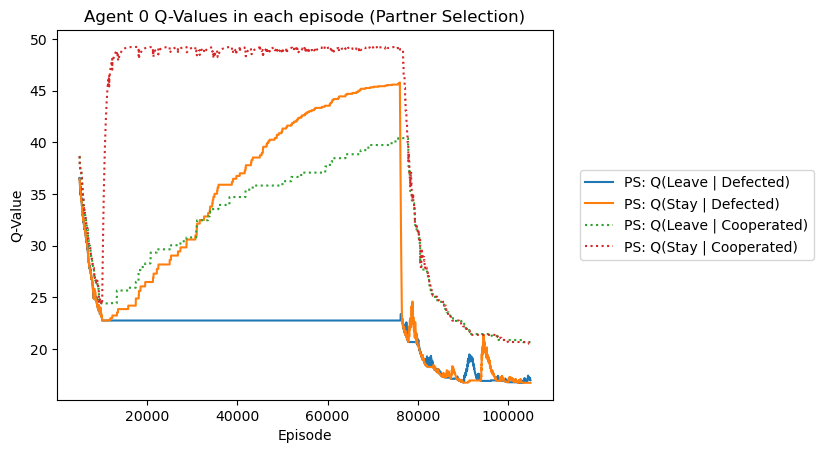

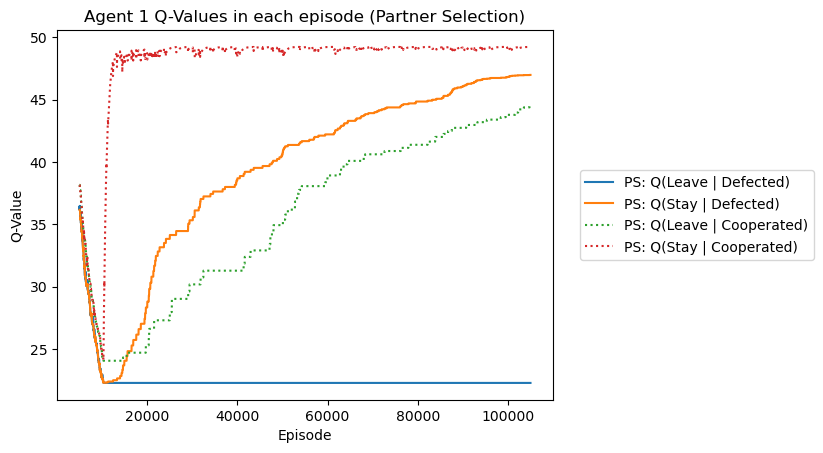

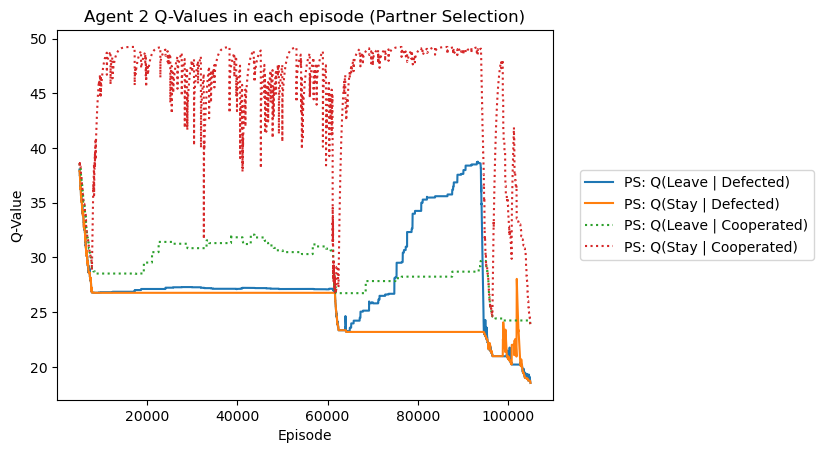

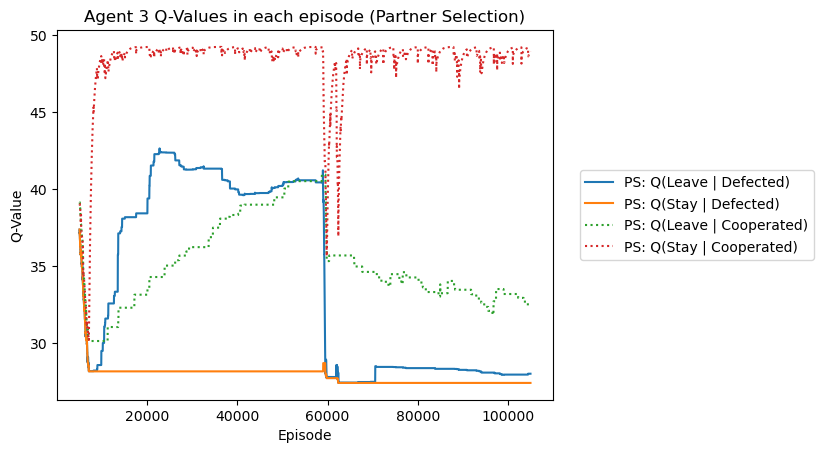

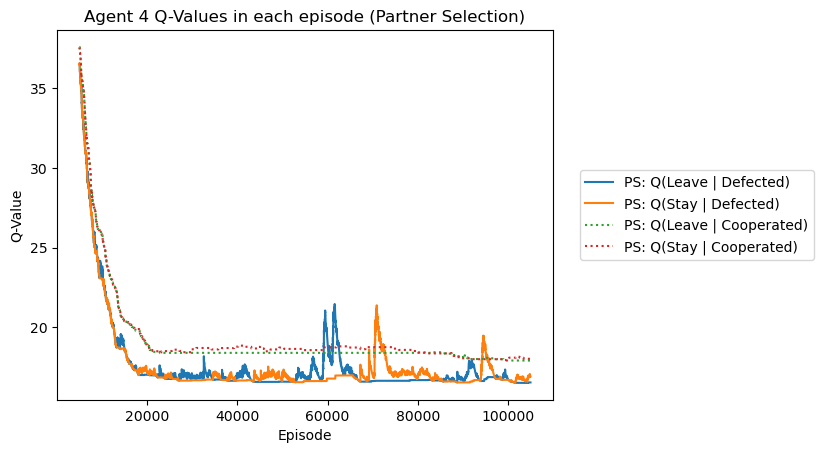

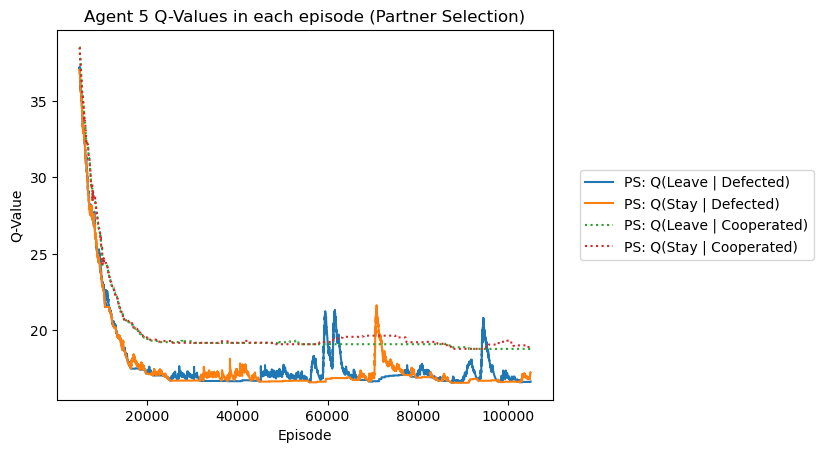

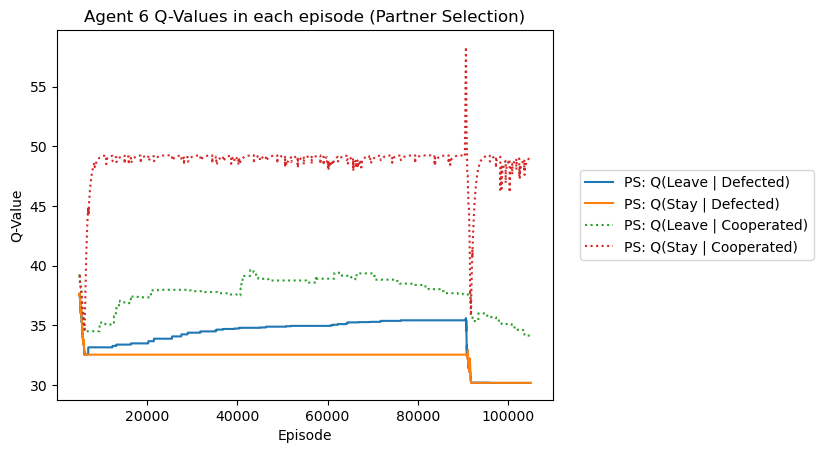

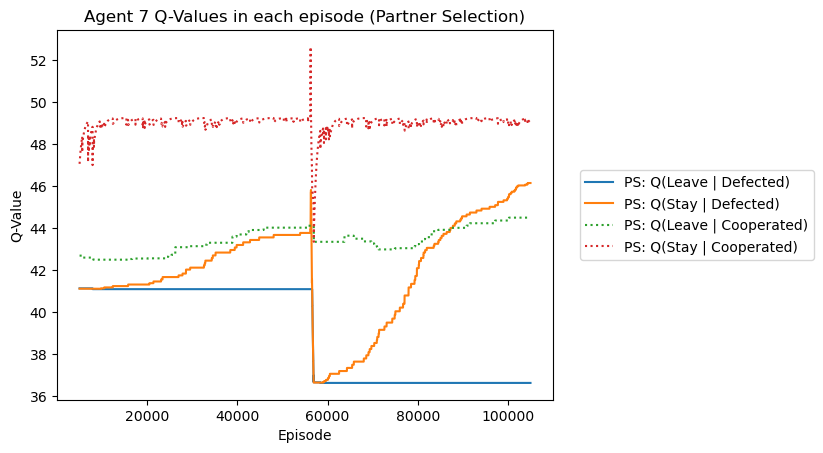

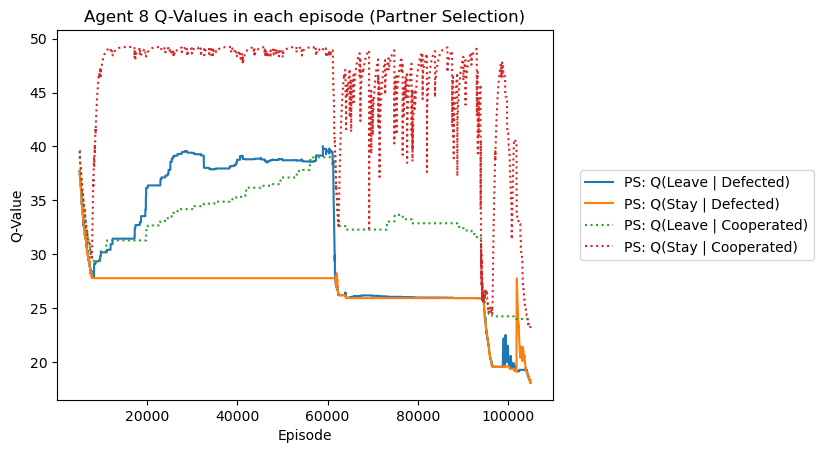

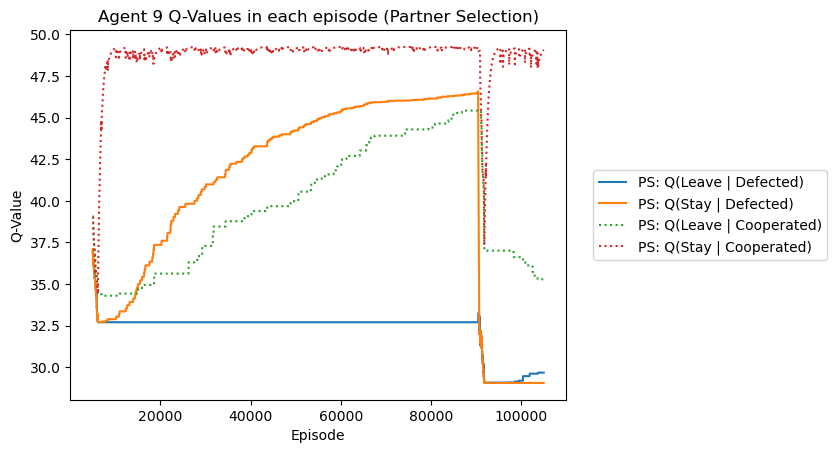

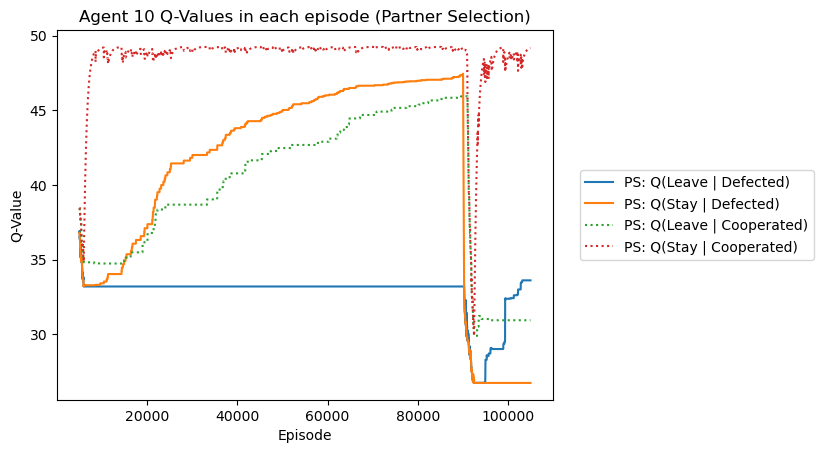

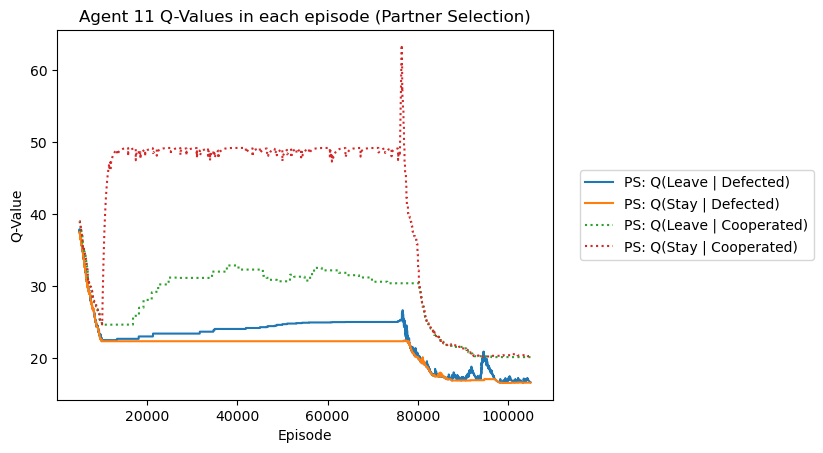

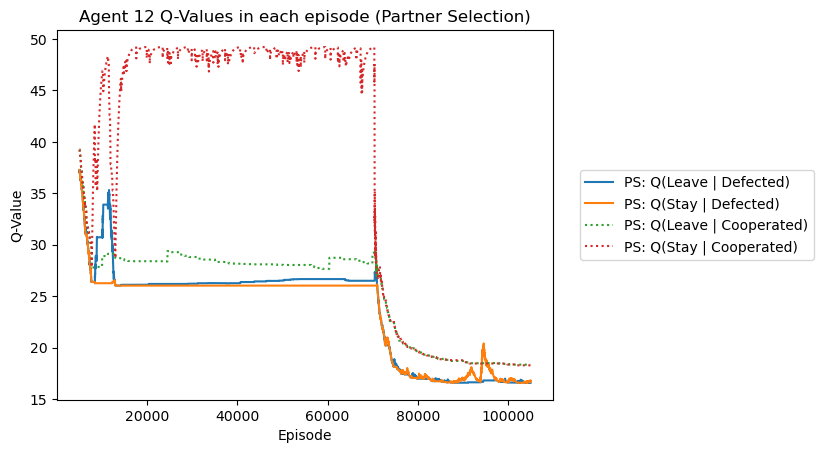

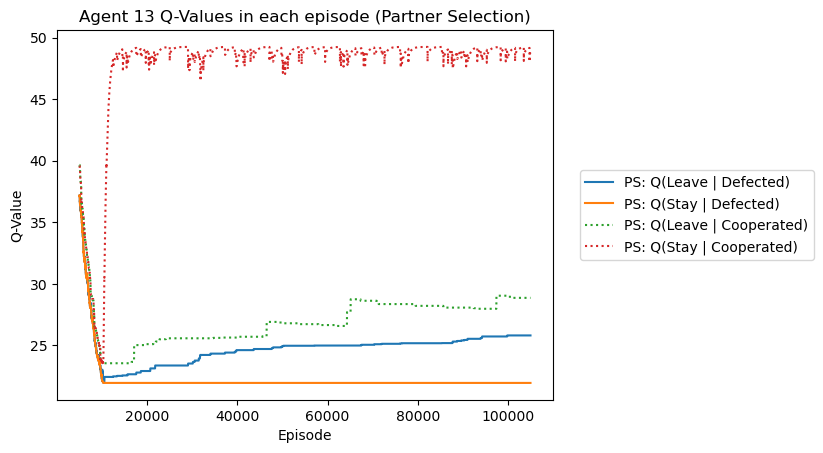

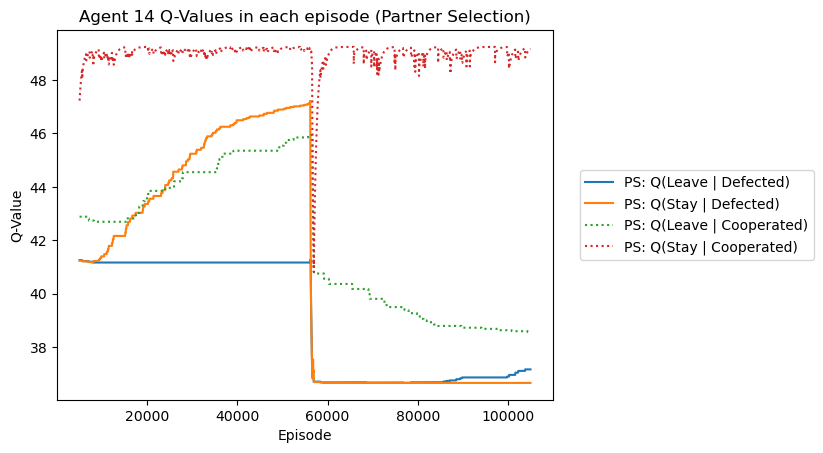

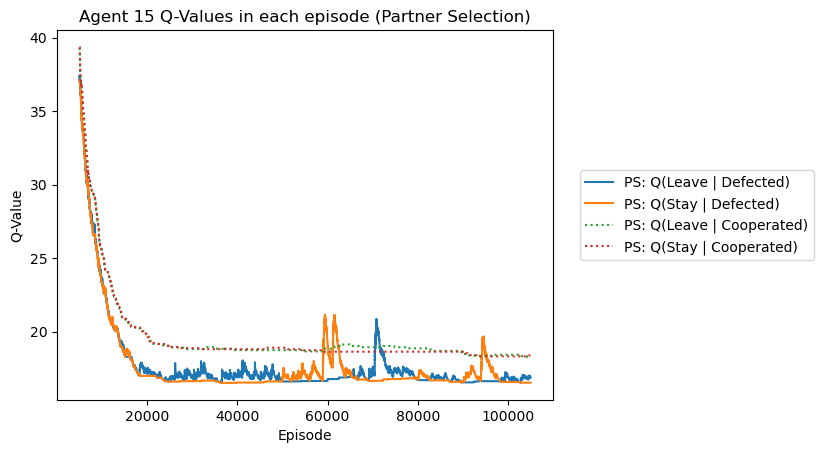

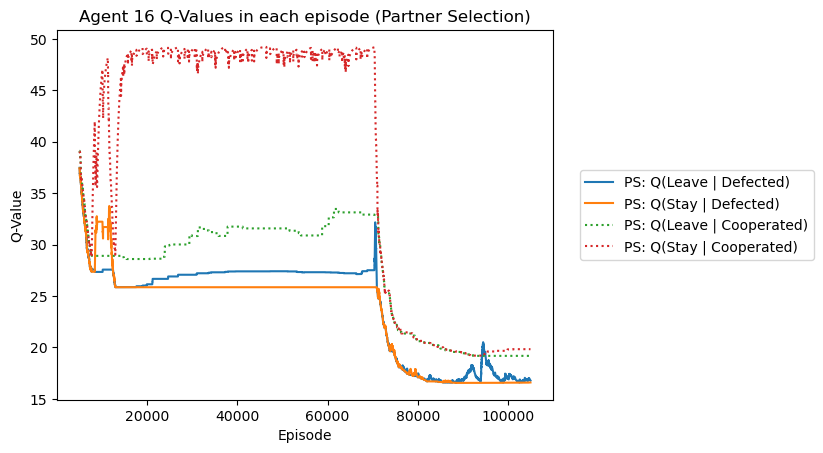

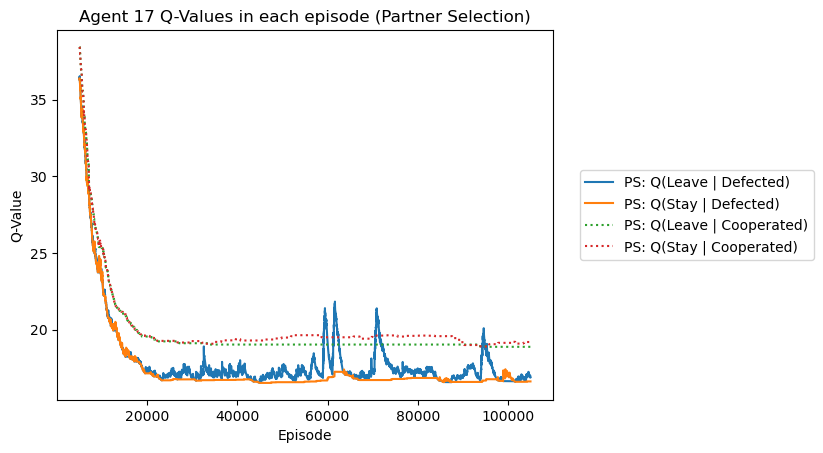

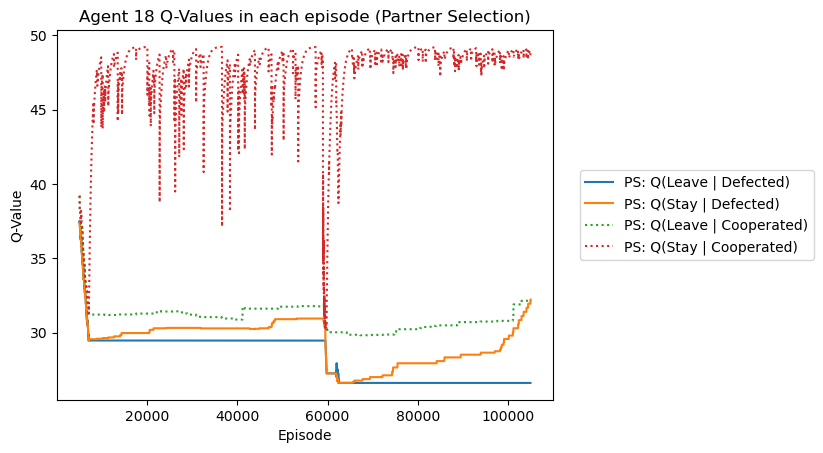

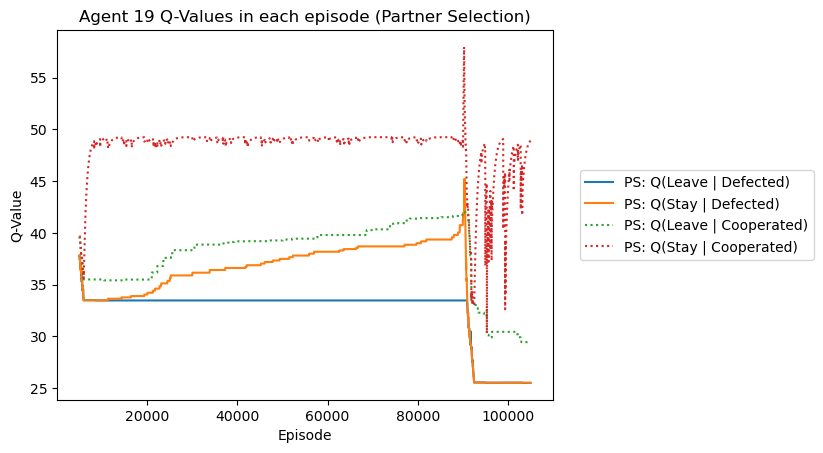

######################################################################################################################################################
######################################################################################################################################################
population: 20
rounds: 1
learning_mode: q_learning
learning_rate: 0.05
discount_rate: 0.97
starting_qvalue: 100.0
starting_state: None
policy_mode: epsilon_greedy
start_decay_episode: 0
end_decay_episode: 0
starting_temperature: 0.002
decay_type: linear
delta_t: 0.0
disposition: 0.0
know_fresh_agent: 1.0
prefer_same_pool: 0.0
prefer_different_pool: 0.0
episodes: 1000000
reps: 1
######################################################################################################################################################
######################################################################################################################################################

Changing var: 

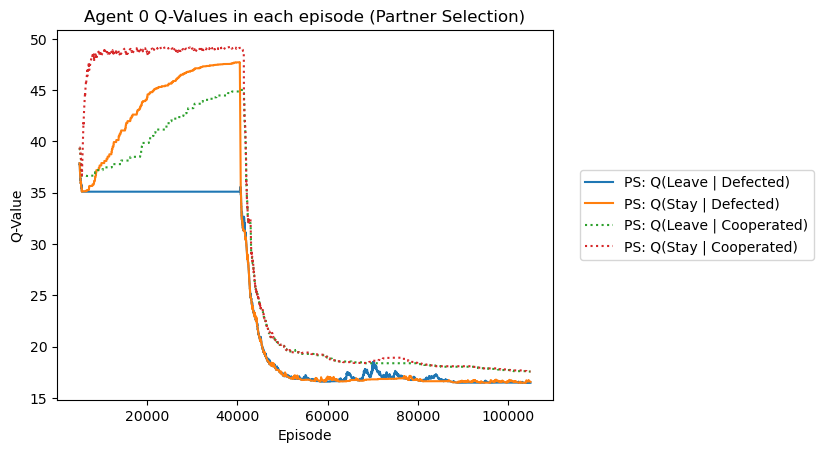

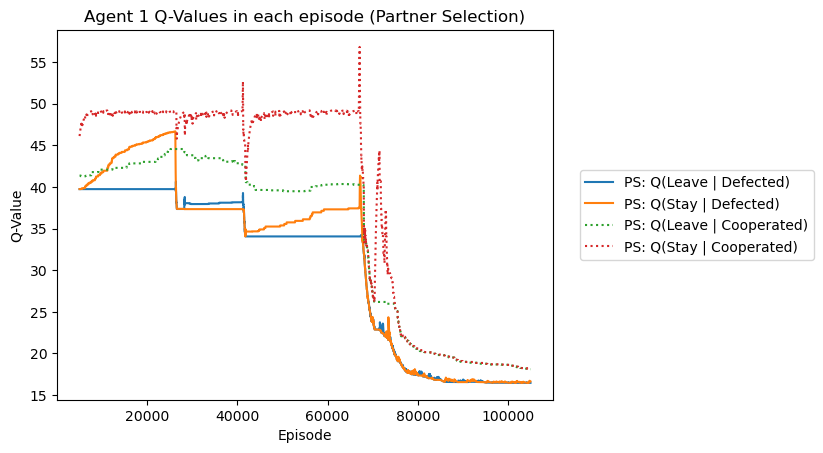

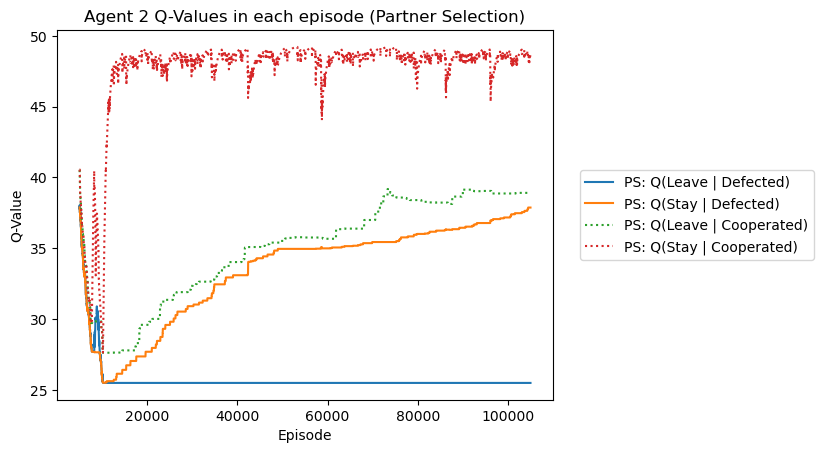

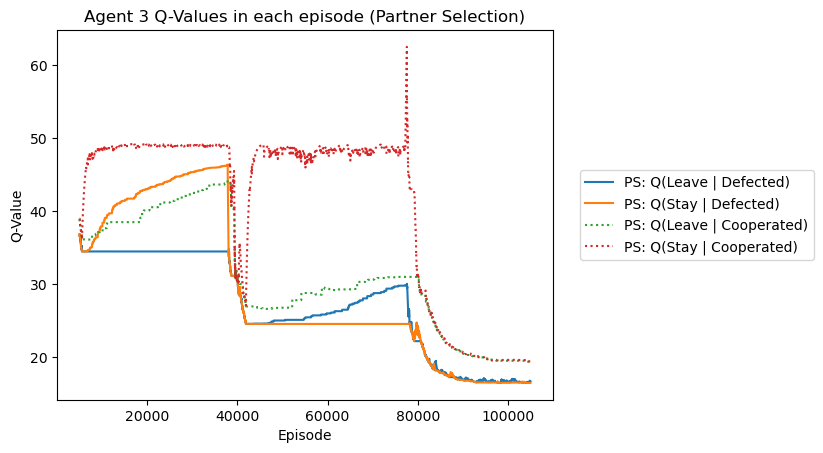

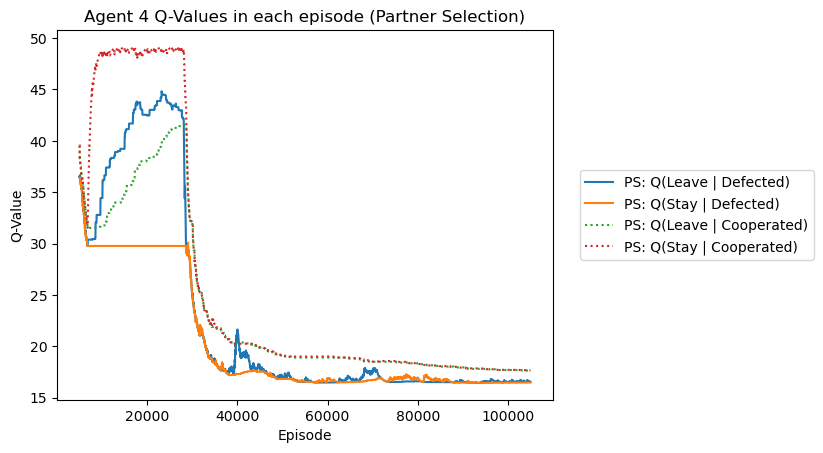

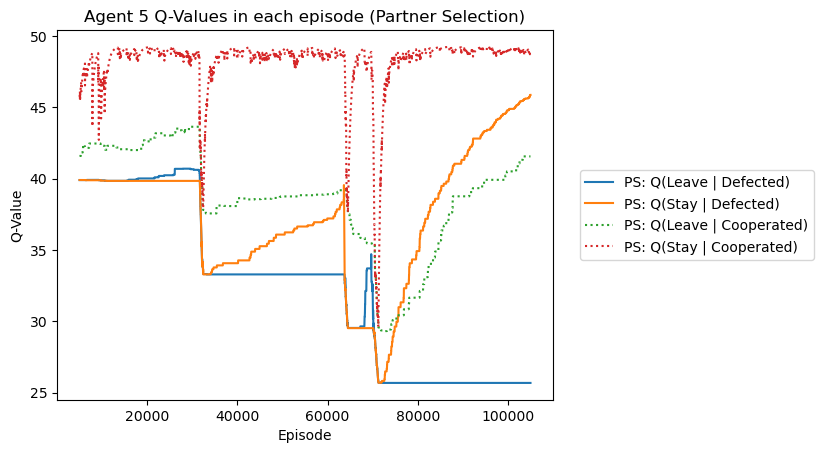

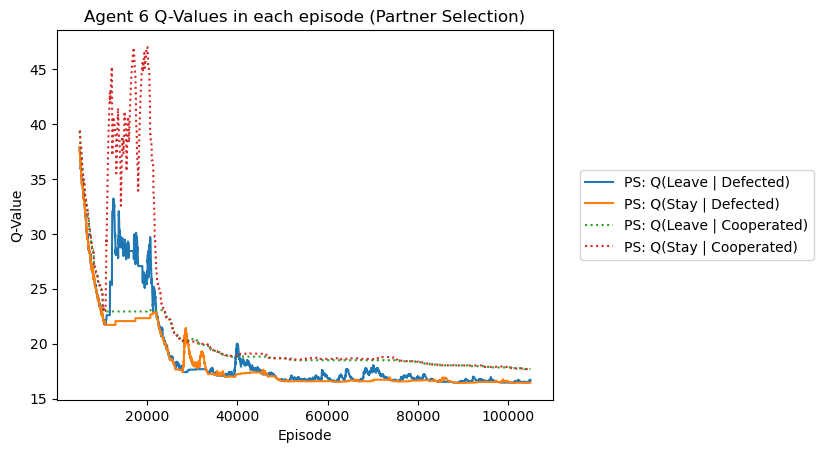

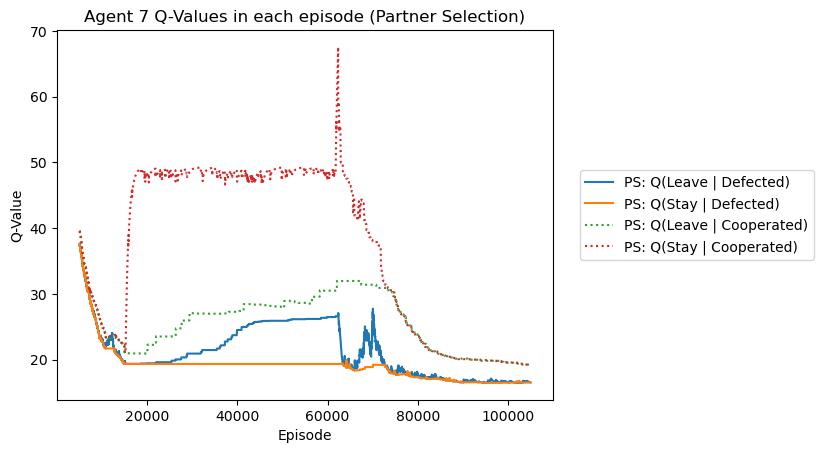

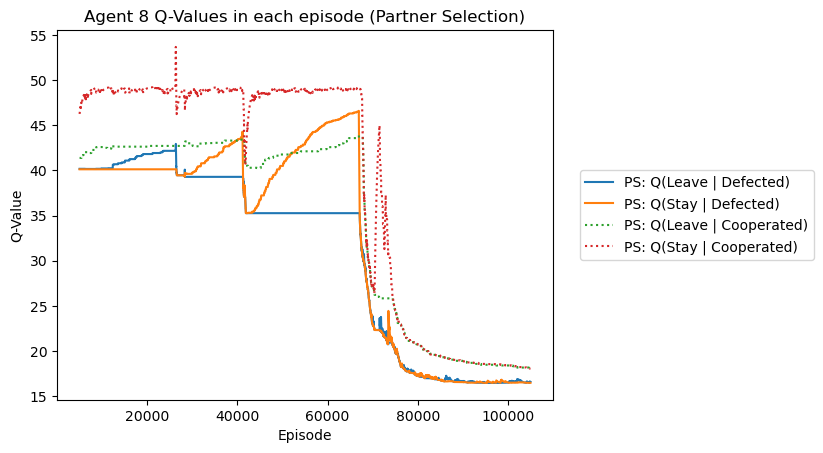

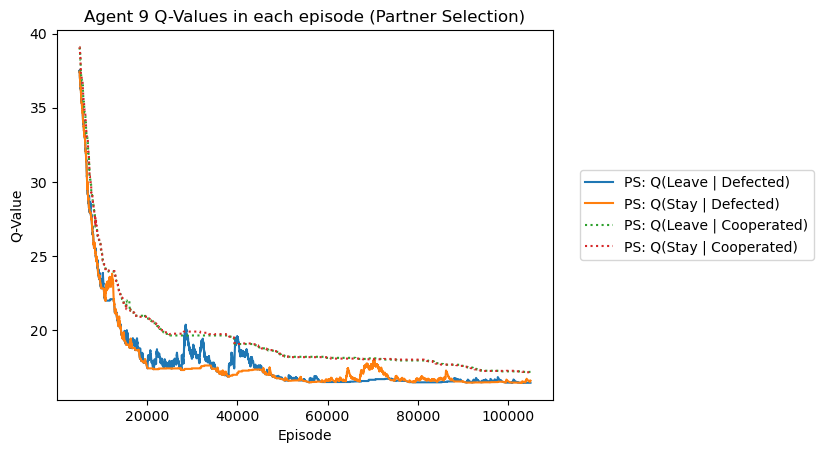

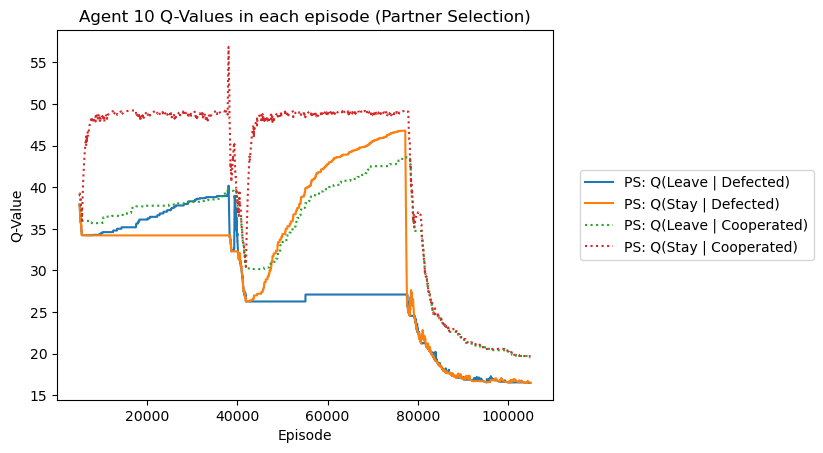

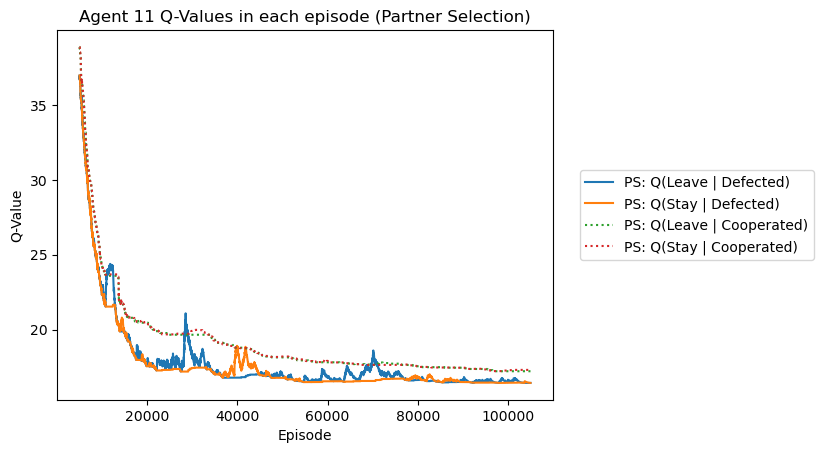

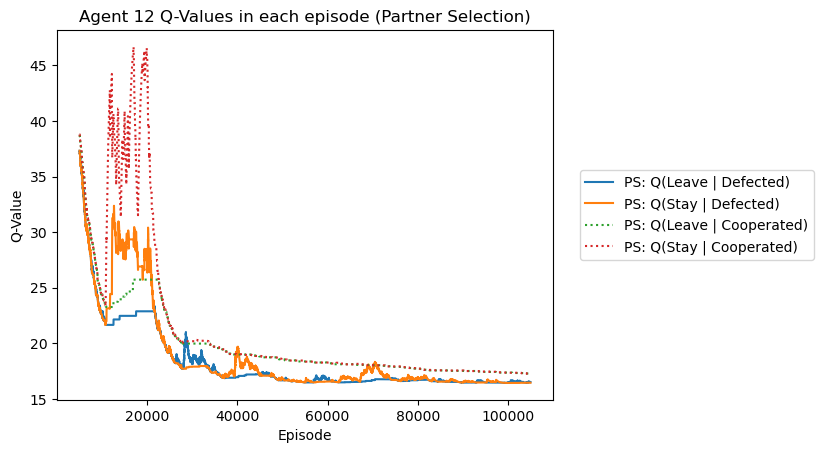

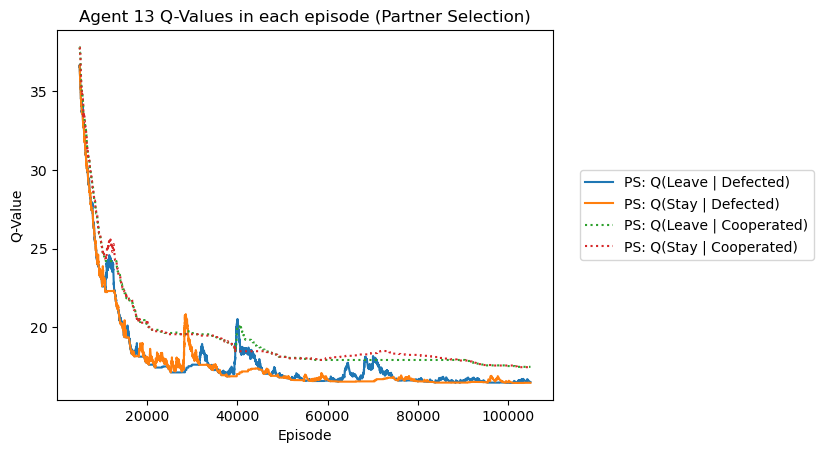

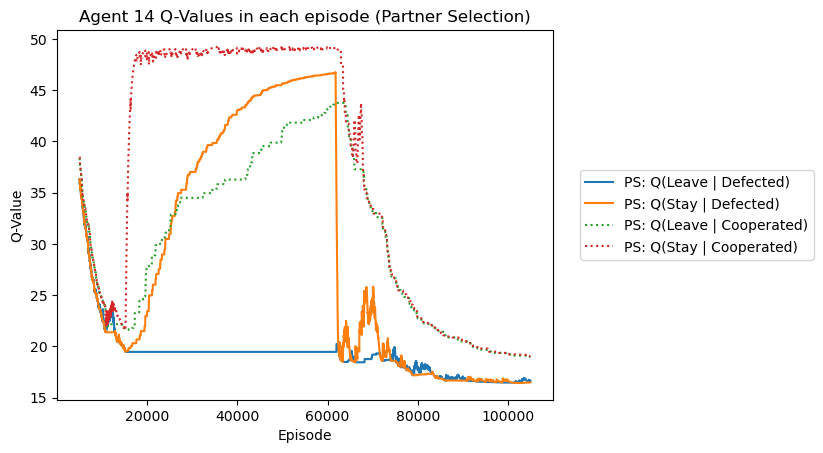

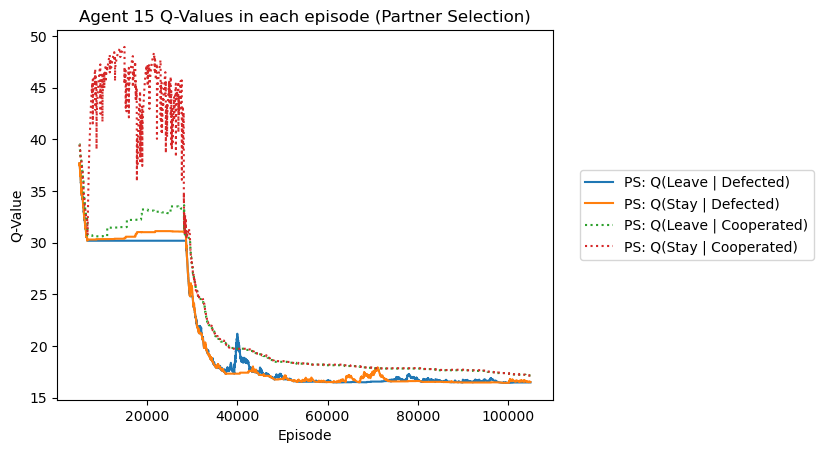

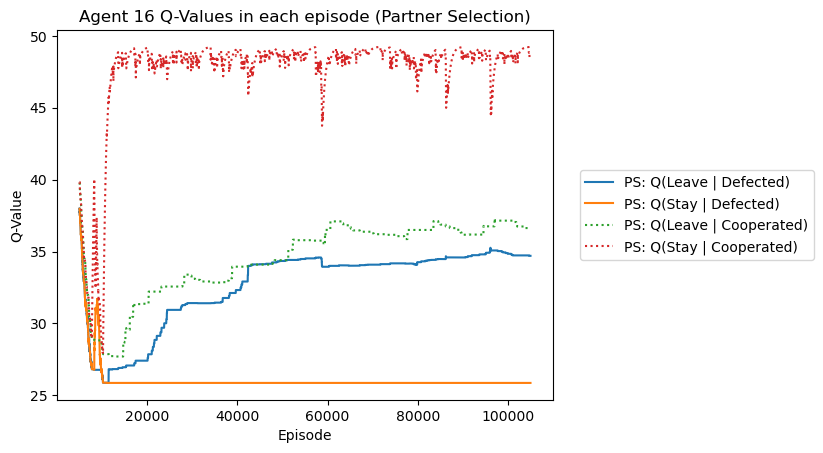

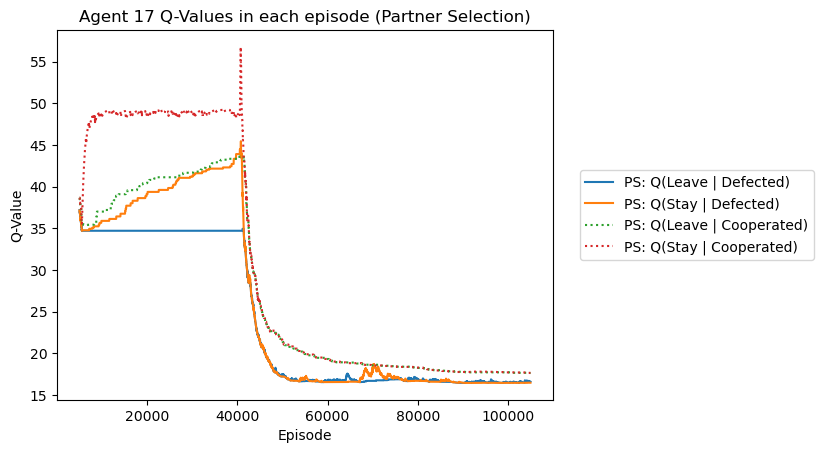

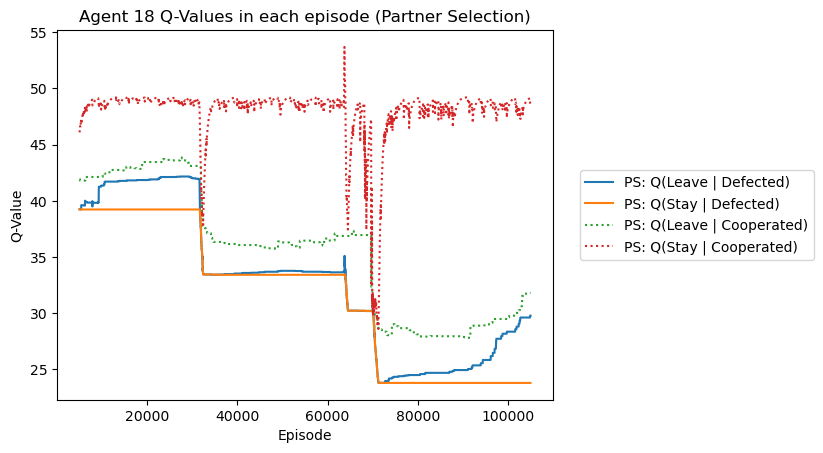

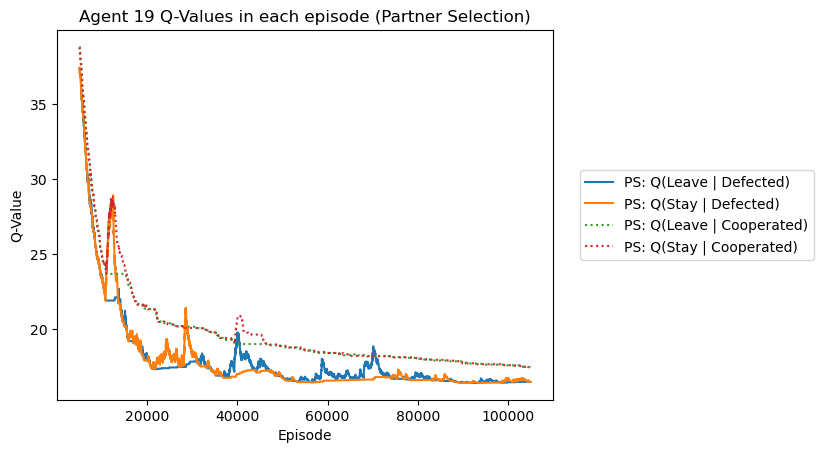

$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
plot/612_Constant_epsilon.pkl
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

######################################################################################################################################################
######################################################################################################################################################
population: 20
rounds: 1
learning_mode: q_learning
learning_rate: 0.05
discount_rate: 0.97
starting_qvalue: 100.0
starting_state: None
policy_mode: epsilon_greedy
start_decay_episode: 0
end_decay_episode: 0
starting_temperature: 0.001
decay_type: linear
delta_t: 0.0
disposition: 0.0
know_fresh_agent: 1.0
prefer_same_pool: 0.0
prefer_different_pool: 0.0
episodes: 

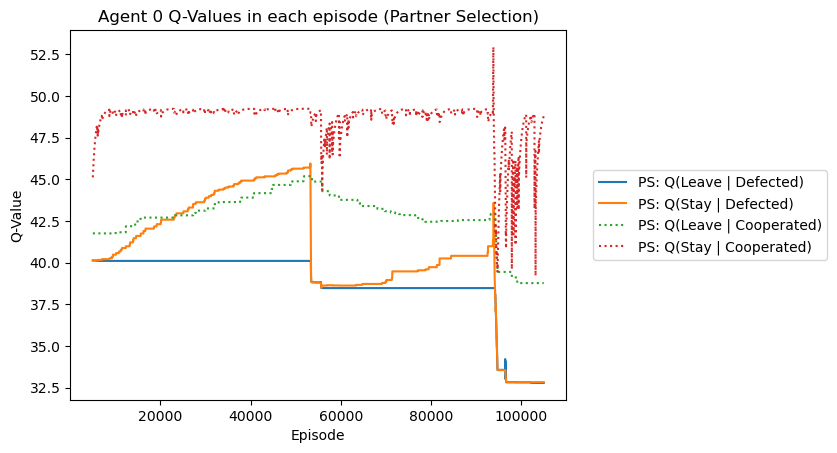

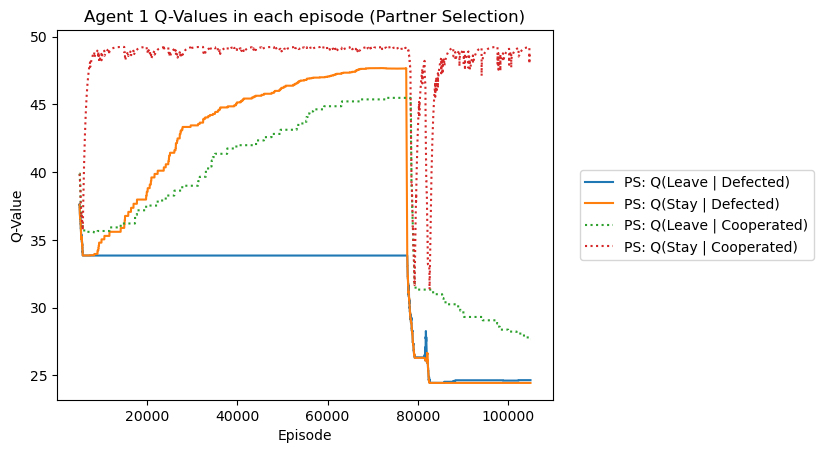

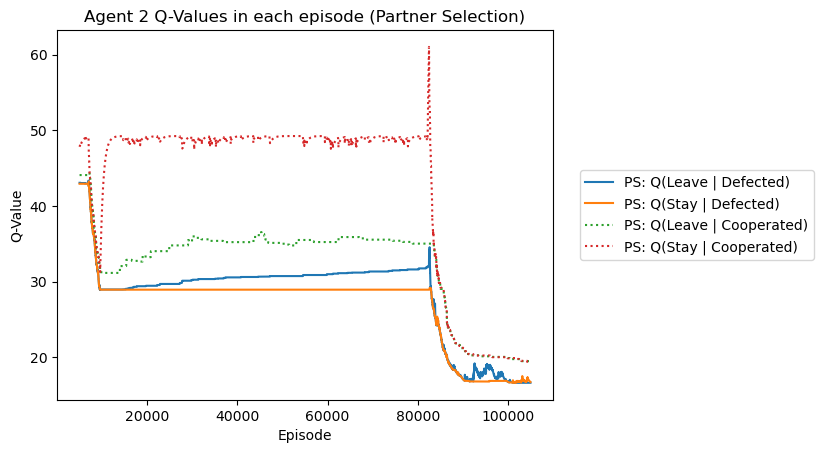

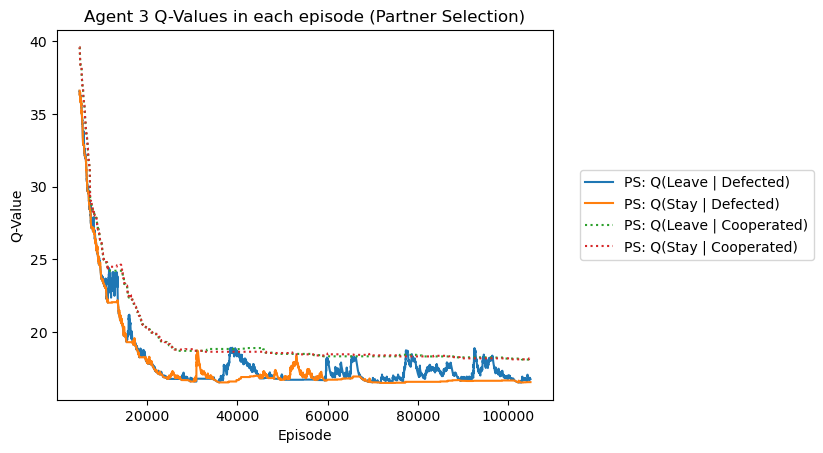

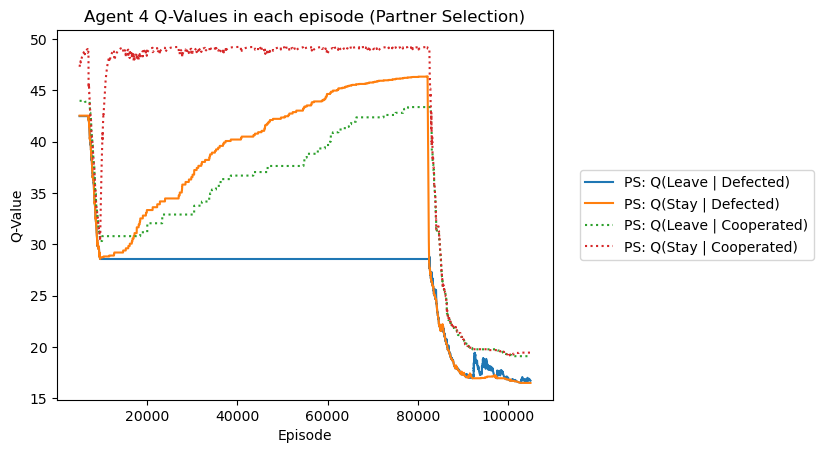

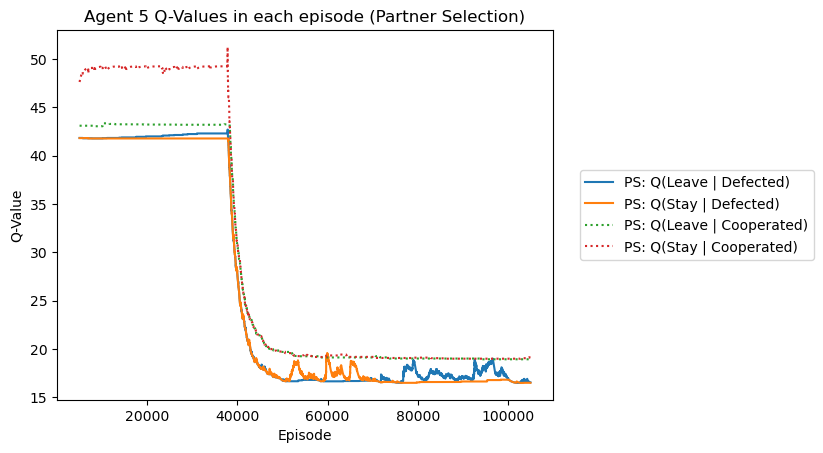

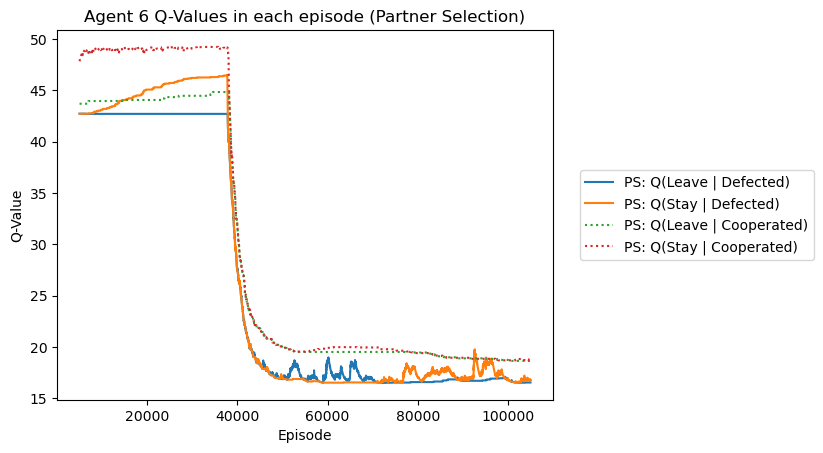

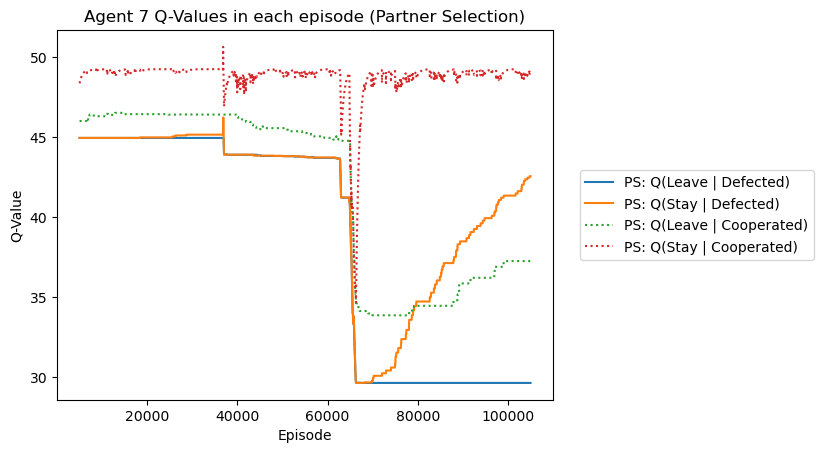

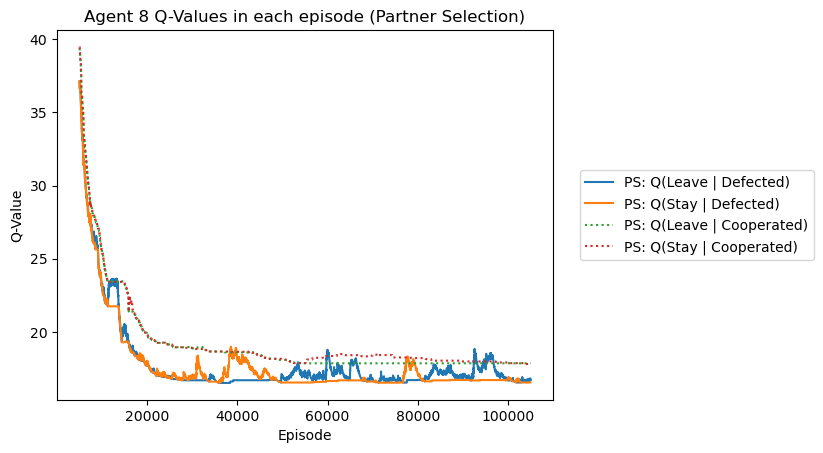

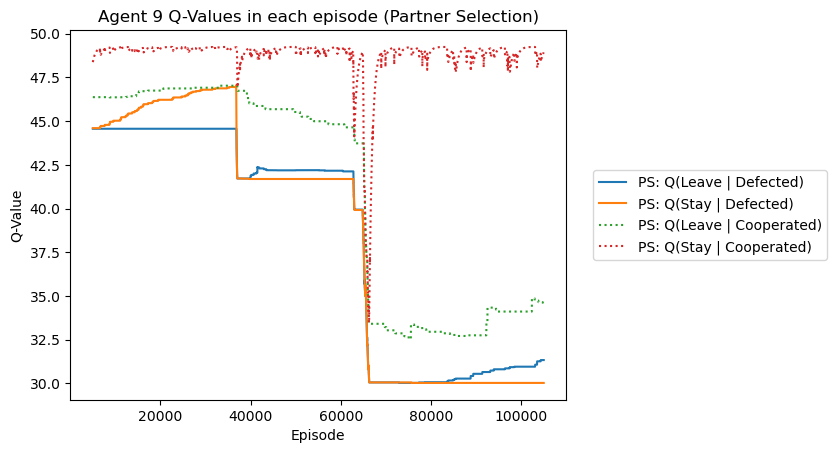

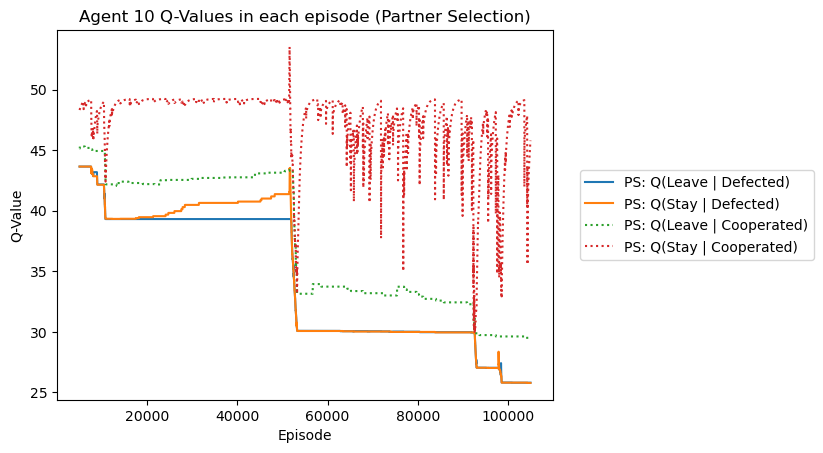

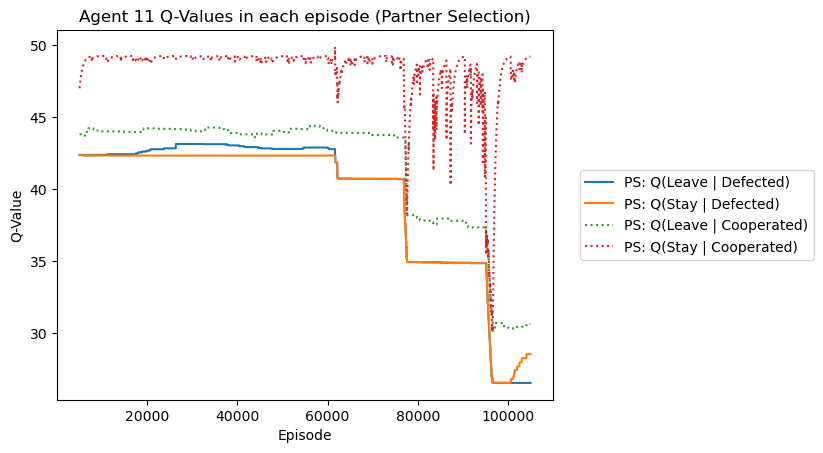

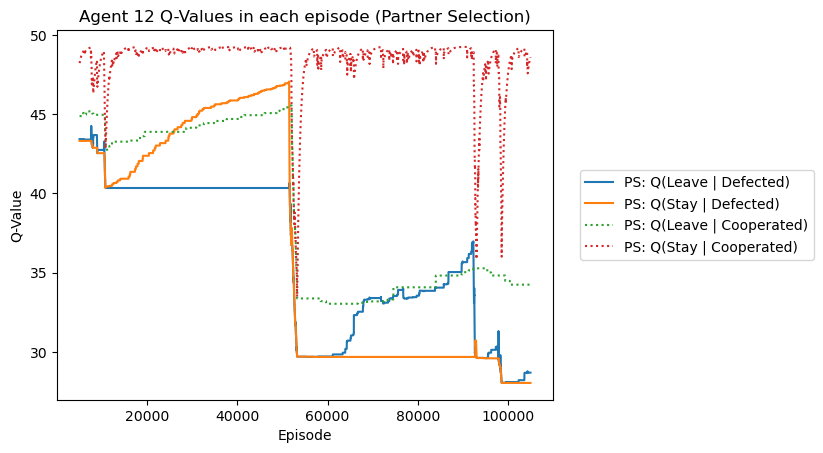

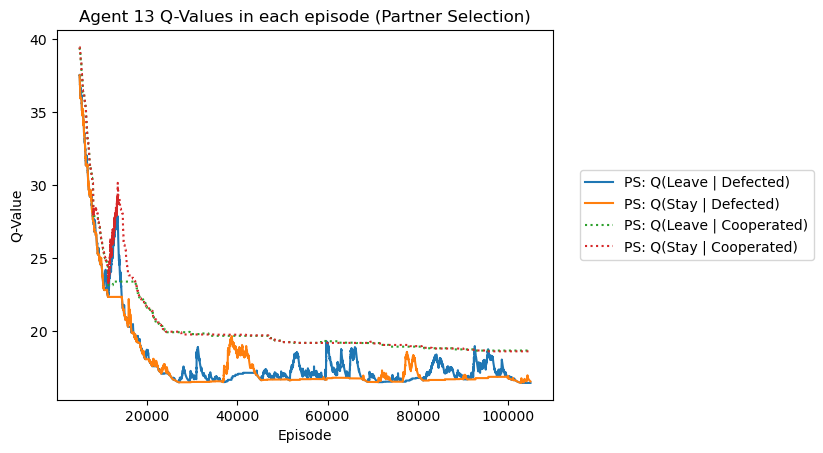

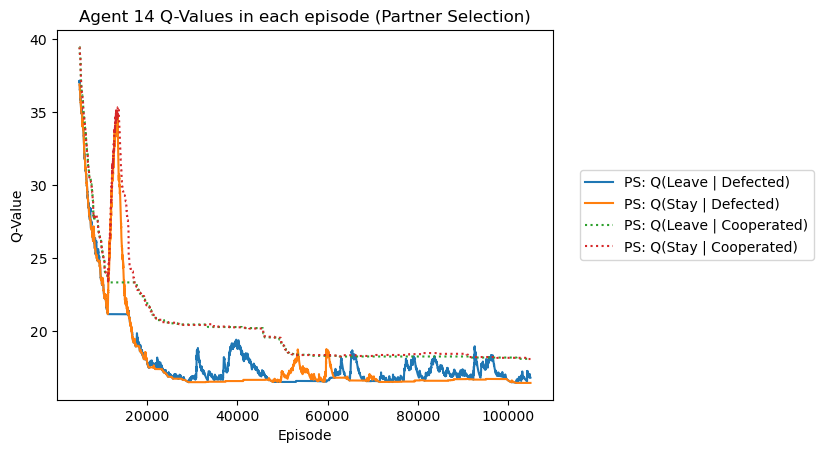

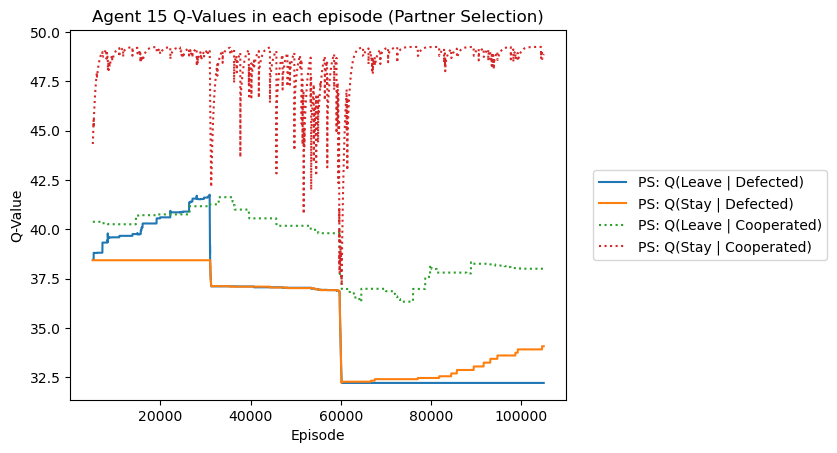

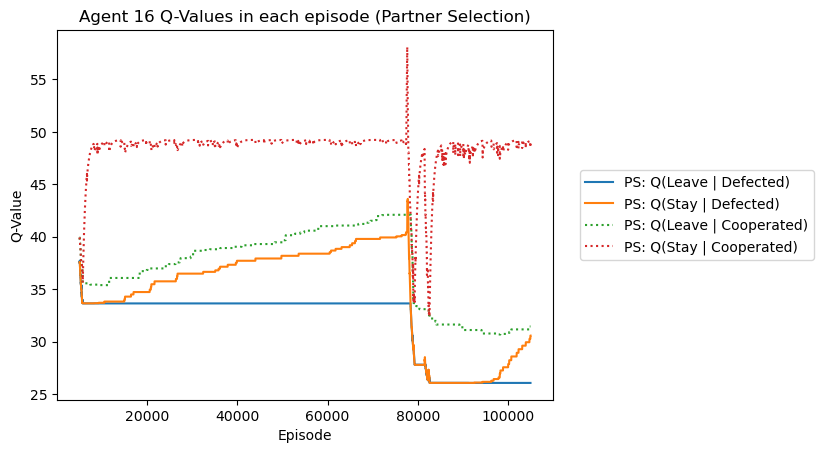

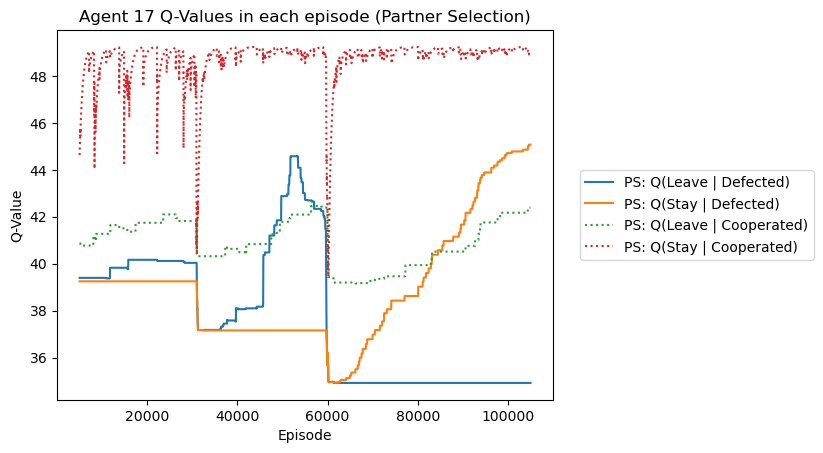

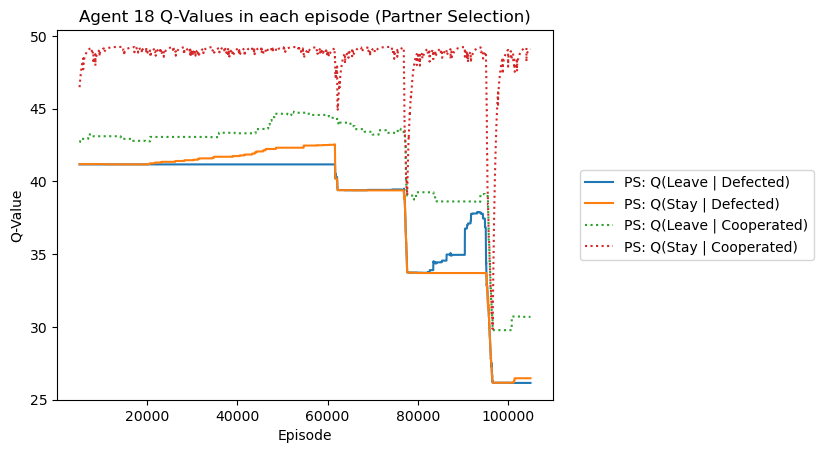

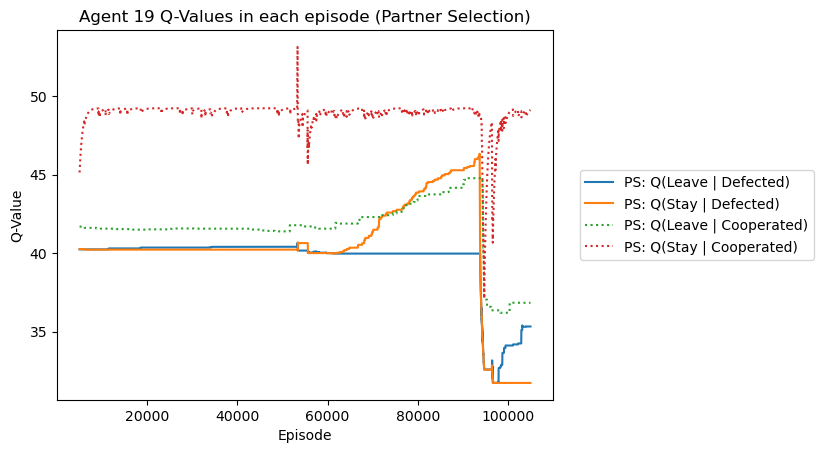

######################################################################################################################################################
######################################################################################################################################################
population: 20
rounds: 1
learning_mode: q_learning
learning_rate: 0.05
discount_rate: 0.97
starting_qvalue: 100.0
starting_state: None
policy_mode: epsilon_greedy
start_decay_episode: 0
end_decay_episode: 0
starting_temperature: 0.002
decay_type: linear
delta_t: 0.0
disposition: 0.0
know_fresh_agent: 1.0
prefer_same_pool: 0.0
prefer_different_pool: 0.0
episodes: 500000
reps: 1
######################################################################################################################################################
######################################################################################################################################################

Changing var: 0

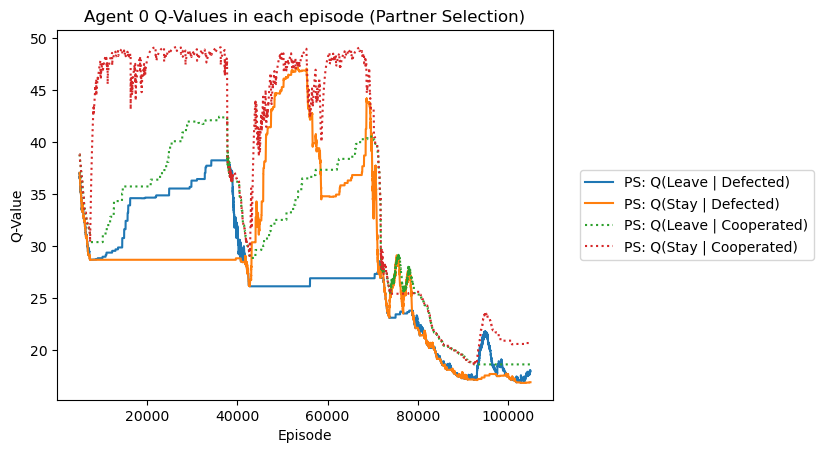

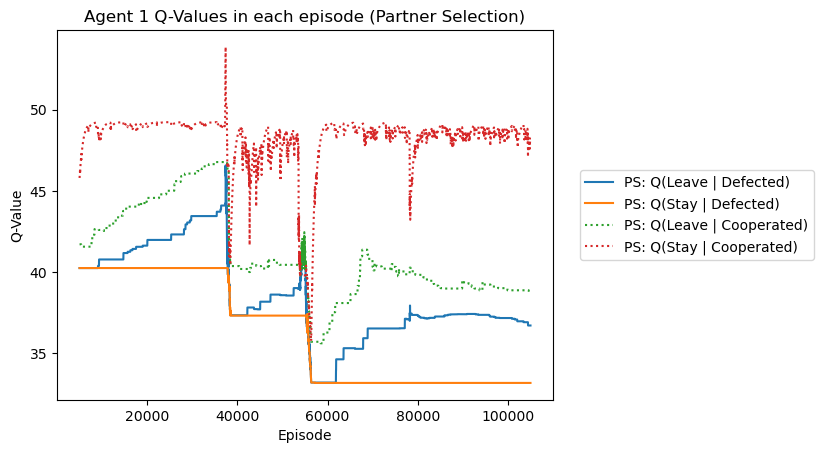

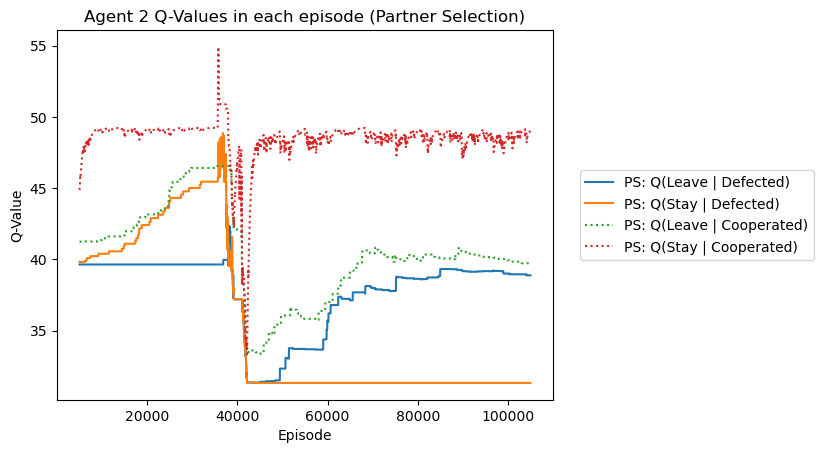

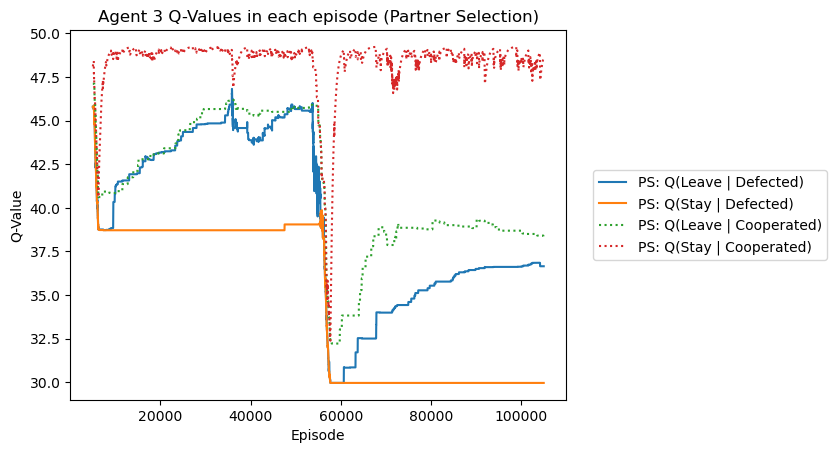

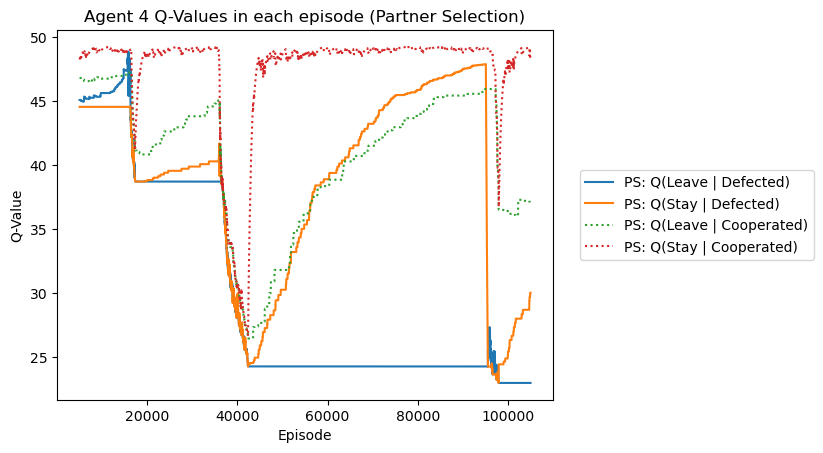

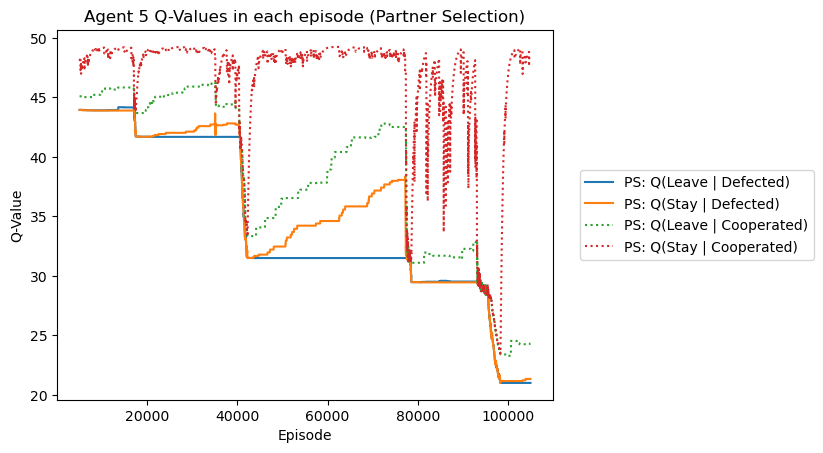

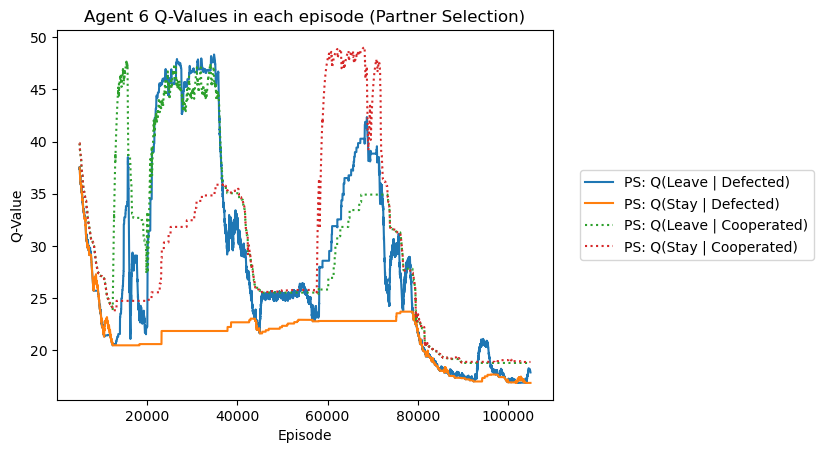

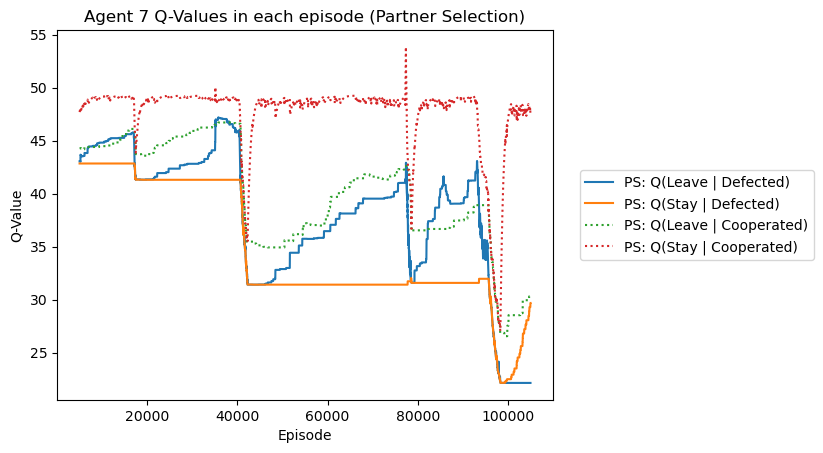

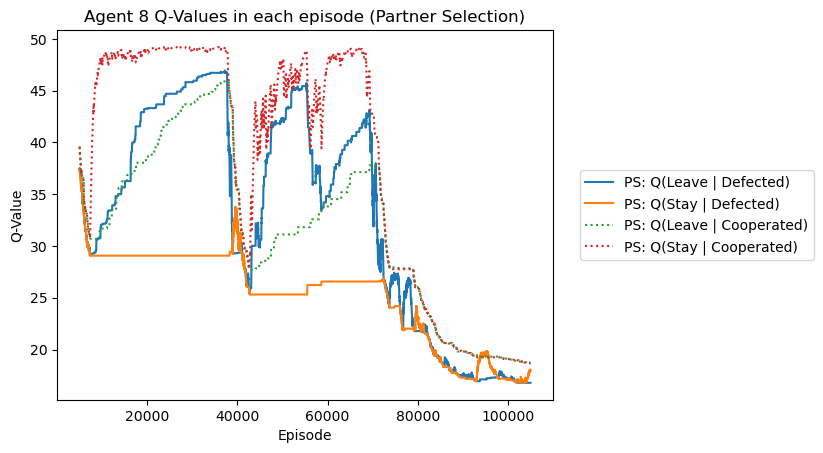

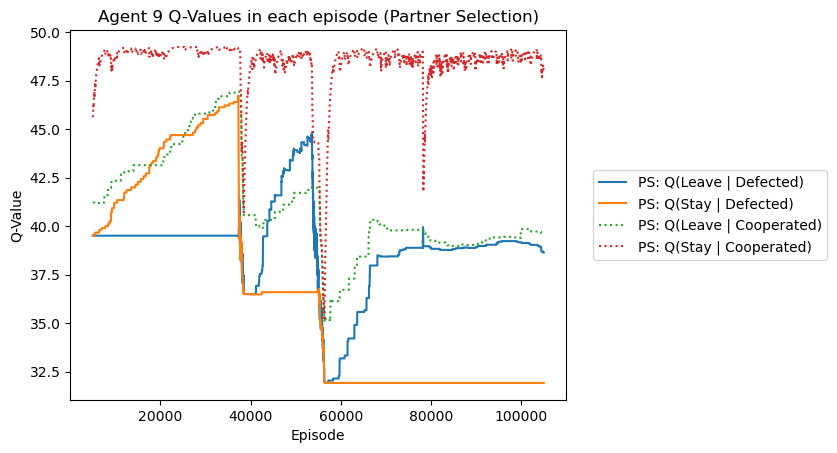

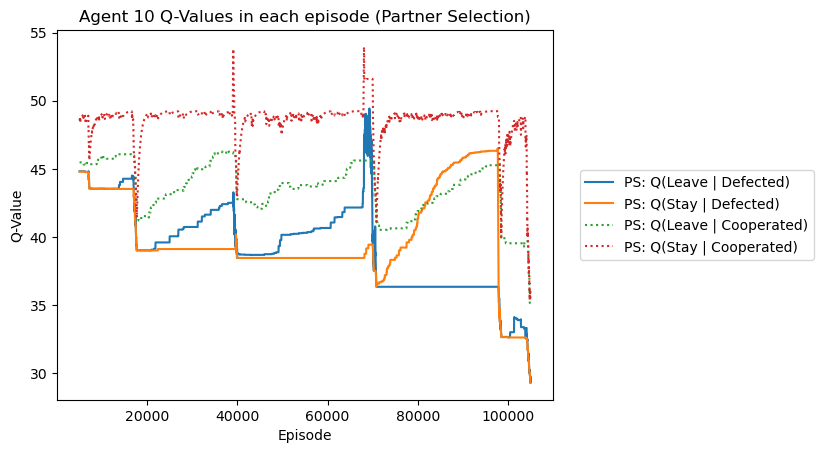

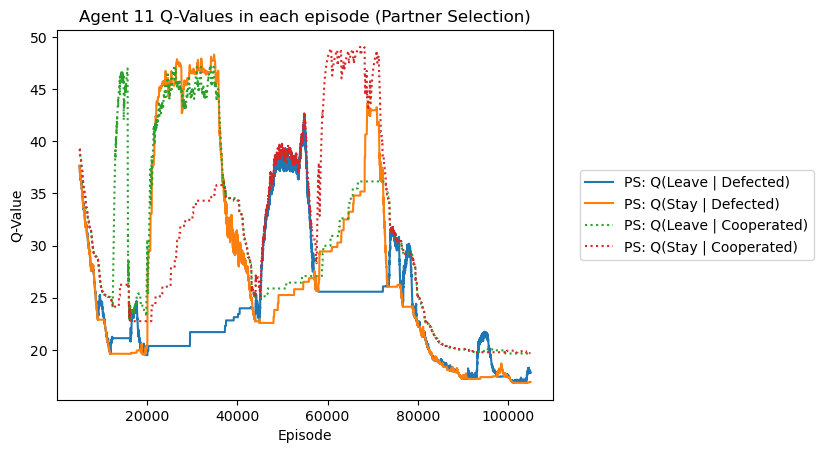

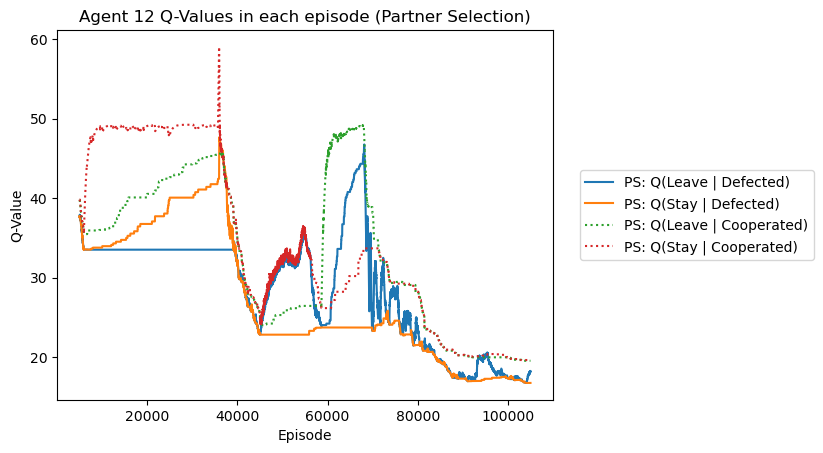

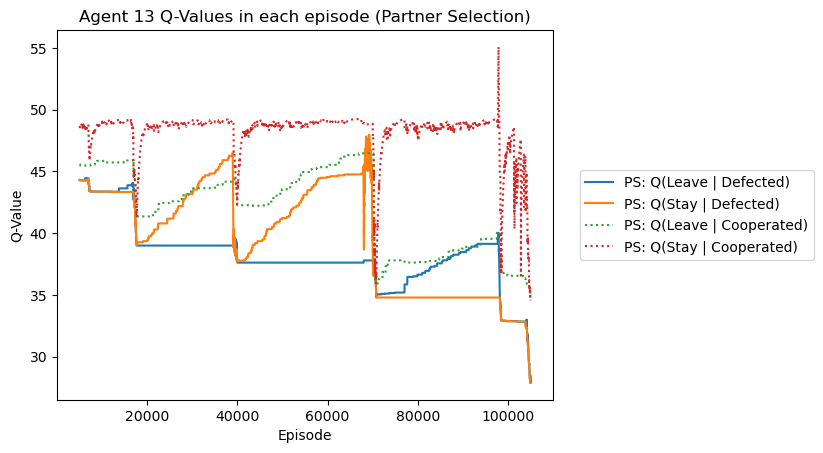

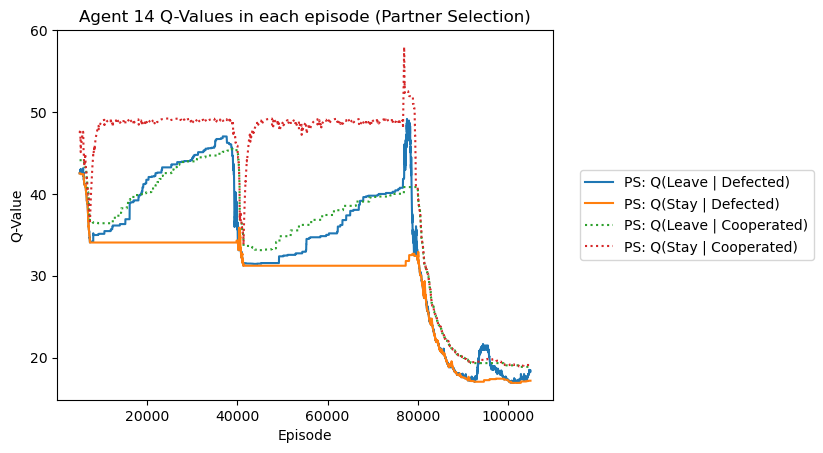

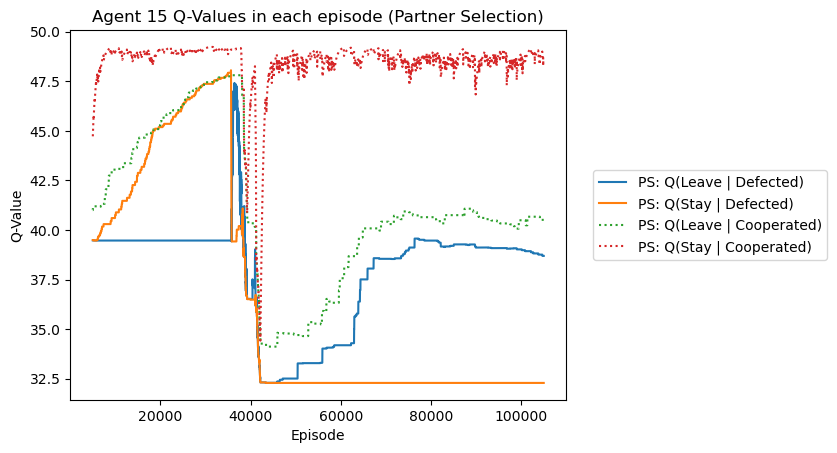

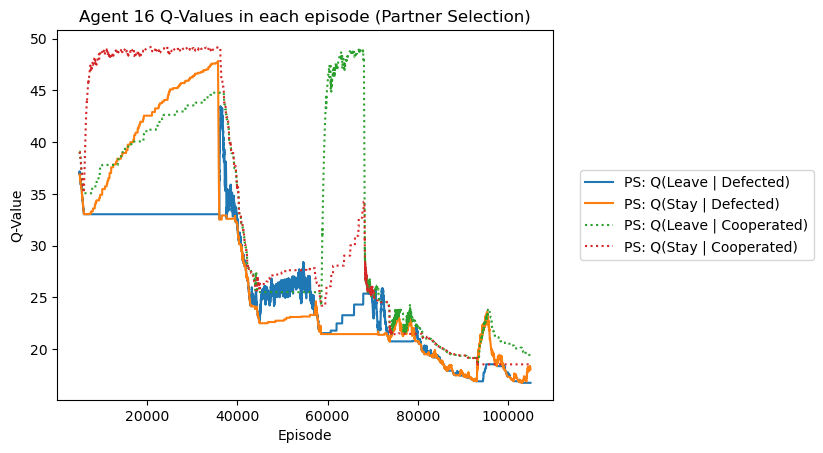

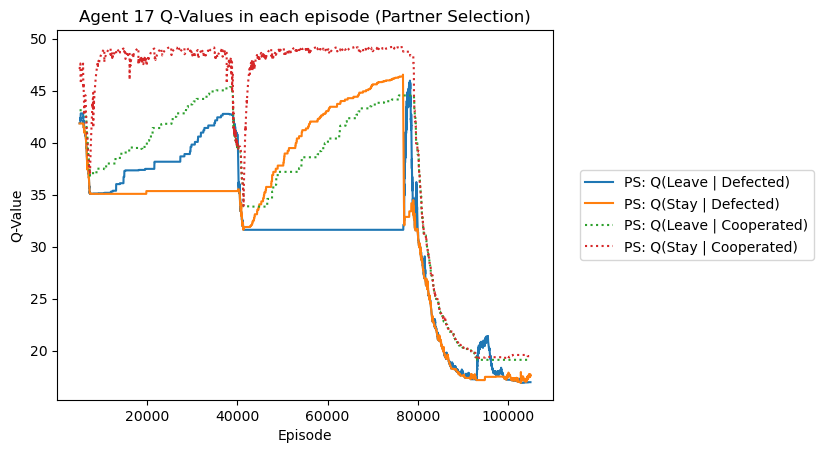

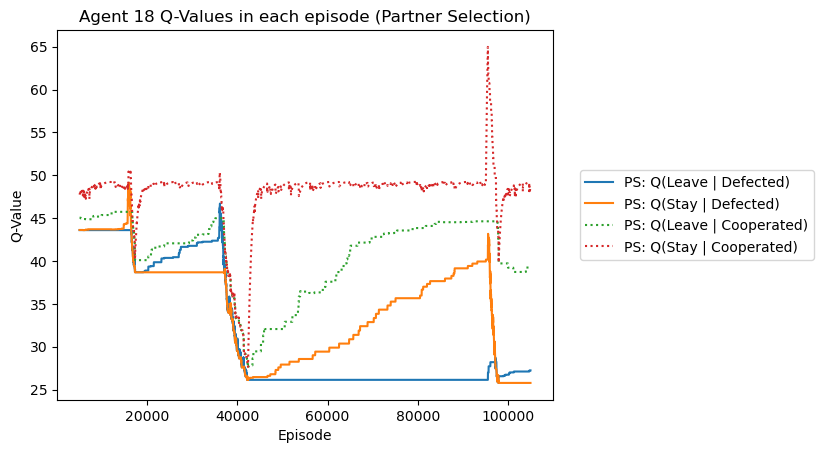

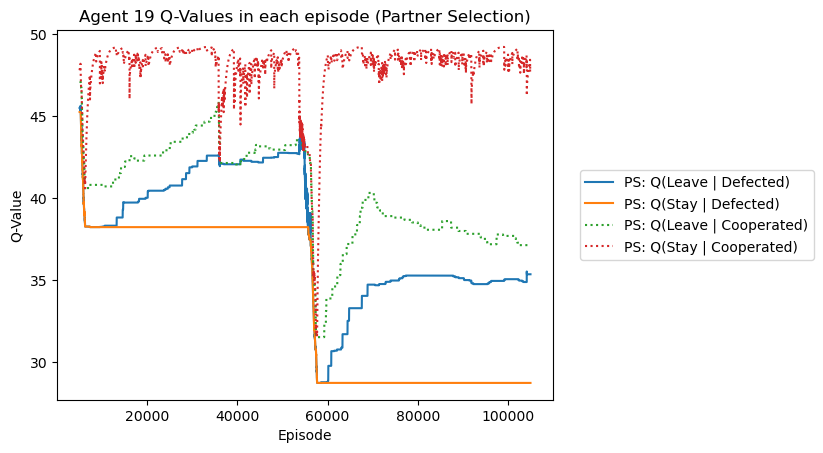

In [4]:
import os
import pickle

# get all filepaths in the "plot" directory
sims = [f"plot/{f}" for f in os.listdir("plot") if f.endswith(".pkl")]

vals_to_plot = "all"
# vals_to_plot = [0.92]

for sim in sims:
    with open(sim, "rb") as f:
        results = pickle.load(f)

    temp_results = results
    for _ in range(1):
        print("$"*150)
    print(sim)
    for _ in range(1):
        print("$"*150)
    print()
    for val, p_r in temp_results.items():
        if vals_to_plot != "all" and val not in vals_to_plot:
            continue
        for _ in range(2):
            print("#"*150)
        for key, value in p_r["params"].items():
            print(f"{key}: {value}")
        for _ in range(2):
            print("#"*150)
        print()
        print("Changing var: %s" % val)
        # print(f"Requires ~{.01/(1.0 - temp):.2f} episodes per 1 at 0.99")
        params = p_r["params"]
        results = p_r["output"]
        print("#"*150)
        print_long_run_vals(params)

        # agents = [1]
        agents = None
        start = 5000
        end = 105000
        # # plot([Plots.TEMPERATURES, Plots.STRATEGIES_PS], results, params, start_episode=start, end_episode=end)
        # # plot([Plots.TEMPERATURES, Plots.STRATEGIES_PD], results, params, start_episode=start, end_episode=end)
        # plot([Plots.TEMPERATURES, Plots.SWITCHED, Plots.CHOSE_SWITCH], results, params, start, end)
        # plot([Plots.TEMPERATURES, Plots.OUTCOMES_PD], results, params, start, end)
        # plot([Plots.TEMPERATURES, Plots.Q_VALUES_AVGS_PD], results, params, start, end)
        # plot([Plots.TEMPERATURES, Plots.Q_VALUES_AVGS_PD], results, params, start, end, clamp=True)


        # plot_agents_qvalues(results, params, do_ps=True, do_pd=True, start_episode=50, end_episode=150)
        # plot_agents_strategies(results, params, do_ps=True, do_pd=False, start_episode=0, end_episode=20000)
        # plot_agents_strategies(results, params, do_ps=False, do_pd=True, start_episode=50, end_episode=150)
        # plot_agents_qvalues(results, params, do_ps=False, do_pd=True, start_episode=0, end_episode=50)
        # plot([Plots.TEMPERATURES, Plots.OUTCOMES_PS, Plots.OUTCOMES_PD], results, params)
        # plot([Plots.TEMPERATURES, Plots.STRATEGIES_PS], results, params, 0, 50)
        # plot([Plots.TEMPERATURES, Plots.STRATEGIES_PD], results, params, 0, 50)
        # plot([Plots.TEMPERATURES, Plots.Q_VALUES_AVGS_PD], results, params, 0, 50)
        # plot([Plots.TEMPERATURES, Plots.Q_VALUES_AVGS_PS], results, params, 0, 50)
        # plot([Plots.TEMPERATURES, Plots.Q_VALUES_AVGS_PS], results, params)
        # plot([Plots.TEMPERATURES, Plots.Q_VALUES_AVGS_PD], results, params)
        # plot([Plots.TEMPERATURES, Plots.COOPERATE_STREAK_AVGS], results, params)
        # plot_agents_qvalues(results, params, do_pd=True)
        # plot_agents_qvalues(results, params, do_ps=True, do_pd=False, start_episode=start, end_episode=end, agents=agents)
        # # plot_agents_qvalues(results, params, do_ps=False, do_pd=True, start_episode=start, end_episode=end, agents=agents, clamp=True)
        plot_agents_qvalues(results, params, do_ps=True, do_pd=False, start_episode=start, end_episode=end, agents=agents)
        # plot_agents_strategies(results, do_ps=True, do_pd=False, start_episode=start, end_episode=end, agents=agents)
        # plot_agents_strategies(results, do_ps=False, do_pd=True, start_episode=start, end_episode=end, agents=agents)



$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
plot/avg_2024-11-15_13-53-55.pkl
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

######################################################################################################################################################
######################################################################################################################################################
population: 20
rounds: 20
learning_rate: 0.05
learning_mode: q_learning
policy_mode: epsilon_greedy
starting_temperature: 0.0
discount_rate: 0.99
delta_t: 0.0
decay_type: linear
start_decay_episode: 0
end_decay_episode: 0
disposition: 0.0
know_fresh_agent: 1.0
prefer_same_pool: 0.0
prefer_different_pool: 0.0
starting_qvalue: 200.0
episodes: 3000
reps: 5
######

ValueError: x and y must have same first dimension, but have shapes (25,) and (5,)

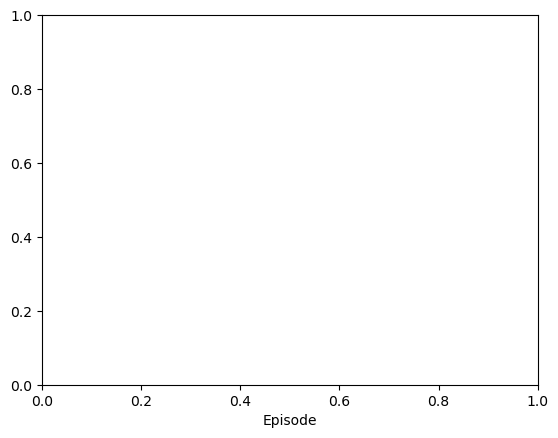

In [8]:
import os
import pickle

# get all filepaths in the "plot" directory
sims = [f"plot/{f}" for f in os.listdir("plot") if f.endswith(".pkl")]

for sim in sims:
    with open(sim, "rb") as f:
        results = pickle.load(f)

    temp_results = results
    for _ in range(1):
        print("$"*150)
    print(sim)
    for _ in range(1):
        print("$"*150)
    print()
    for val, p_r in temp_results.items():
        for _ in range(2):
            print("#"*150)
        for key, value in p_r["params"].items():
            print(f"{key}: {value}")
        for _ in range(2):
            print("#"*150)
        print()
        print("Changing var: %s" % val)
        # print(f"Requires ~{.01/(1.0 - temp):.2f} episodes per 1 at 0.99")
        params = p_r["params"]
        results = p_r["output"]
        print("#"*150)
        print(f"Strategies: {val}")
        plot([Plots.STRATEGIES_PS, Plots.STRATEGIES_PD, Plots.TEMPERATURES], results, 2995, 3020)
        plot([Plots.STRATEGIES_PS, Plots.STRATEGIES_PD, Plots.TEMPERATURES], results, 2995, 3200)
        plot([Plots.STRATEGIES_PS, Plots.STRATEGIES_PD, Plots.TEMPERATURES], results, 2995, None)
        print("#"*150)
        print(f"Q_Values: {val}")
        plot([Plots.Q_VALUES_AVGS_PS, Plots.TEMPERATURES], results, 2995, 3020)
        plot([Plots.Q_VALUES_AVGS_PD, Plots.TEMPERATURES], results, 2995, 3020)
        plot([Plots.Q_VALUES_AVGS_PS, Plots.TEMPERATURES], results, 2995, 3200)
        plot([Plots.Q_VALUES_AVGS_PD, Plots.TEMPERATURES], results, 2995, 3200)
        plot([Plots.Q_VALUES_AVGS_PS, Plots.TEMPERATURES], results, 2995, None)
        plot([Plots.Q_VALUES_AVGS_PD, Plots.TEMPERATURES], results, 2995, None)
        print(f"Outcomes: {val}")
        plot([Plots.OUTCOMES_PS], results, 2995, 3020)
        plot([Plots.OUTCOMES_PD], results, 2995, 3020)
        plot([Plots.OUTCOMES_PS], results, 2995, 3200)
        plot([Plots.OUTCOMES_PD], results, 2995, 3200)
        plot([Plots.OUTCOMES_PS], results, 2995, None)
        plot([Plots.OUTCOMES_PD], results, 2995, None)

        
        # plot([Plots.TEMPERATURES, Plots.STAY_STREAK_AVGS, Plots.LEAVE_STREAK_AVGS, Plots.COOPERATE_STREAK_AVGS, Plots.DEFECT_STREAK_AVGS], results)
